In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
from pathlib import Path
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr
import pickle
import matplotlib.pyplot as plt


In [2]:
# Outputs (concordance CSVs, rank distributions, histograms) all go here.
# Using an absolute path so it does not matter what cwd the notebook is run from.
OUTPUT_DIR = Path('/home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Notebook outputs → {OUTPUT_DIR}')


Notebook outputs → /home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings


In [3]:
perturbationStrength=pd.read_csv("/home/beraslan/Projects/ChemoGeneticScreens/TextFiles/perturbation_by_drug_nsig_genes_fdr_lt_0p1.csv", index_col=0)

In [4]:
# Load the rowbound matrix produced by notebook 10's "looser filters" cell:
#   - rows: PosteriorMean_matrix_<drug>::<perturbation> for the union of perts
#           significant in ≥1 drug context (1,933 perts × 16 drugs)
#   - cols: response genes with MEDIAN-across-drugs > 40 (~14,639 genes)
a = pd.read_csv(
    "/home/beraslan/Projects/ChemoGeneticScreens/TextFiles/PosteriorMeanMatrices_rowbound_anyDrugSig_geneMed40.csv",
    index_col=0,
)
print(a.shape)

(30704, 14639)


In [6]:
a

,SFRP1,APOE,TUBB2B,PDLIM1,COL6A1,TPM1,POU5F1,AASS,SERPINB9,FTL,...,BMP8B,RGS19,FRMD3,ANKS1A,OR2L2,THSD7B,AP4S1,MYL11,KLRG1,BCL2
PosteriorMean_matrix_AR-A014418::A1BG,0.019141,0.001280,-0.003251,0.003372,0.004118,0.002244,0.005220,0.000936,0.000756,-0.000096,...,0.000161,-0.000278,-0.000033,-0.001630,0.000018,0.000038,-0.000490,-0.000099,0.000037,-0.000187
PosteriorMean_matrix_AR-A014418::AASS,0.005622,-0.037648,-0.039193,0.000646,0.006335,0.001698,0.011338,-2.547604,0.000018,0.000579,...,0.000073,0.000080,0.000592,0.000794,-0.000556,-0.000163,0.000720,0.000141,0.000437,-0.000612
PosteriorMean_matrix_AR-A014418::ABCB6,0.000297,0.000286,-0.000155,-0.002614,-0.001033,0.000032,-0.000139,-0.004492,0.001876,-0.004256,...,0.000086,0.000012,0.000085,-0.000356,-0.000020,0.000066,0.000289,0.000225,-0.000070,-0.000435
PosteriorMean_matrix_AR-A014418::ABCC5,0.028030,-0.000482,-0.000040,-0.000463,0.023774,0.000157,0.000047,-0.000506,0.001478,-0.000222,...,0.000075,-0.000166,-0.000538,0.000130,-0.000556,-0.000093,0.000213,-0.000099,0.000930,0.000560
PosteriorMean_matrix_AR-A014418::ABCF3,-0.085573,-0.007372,-0.025086,-0.000795,0.093550,-0.054777,0.016131,0.053351,0.003076,0.003075,...,-0.000104,-0.000325,-0.000091,-0.000930,0.000105,-0.000126,-0.002549,-0.000042,-0.007025,-0.000100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PosteriorMean_matrix_VX-11e::ZSCAN21,-0.001577,0.175078,0.001494,0.227127,-0.137962,0.001452,-0.358448,-0.405158,-0.120059,0.220939,...,-0.001502,-0.023397,-0.000112,0.000470,-0.000113,-0.000367,0.000079,-0.000121,0.000032,-0.005639
PosteriorMean_matrix_VX-11e::ZSCAN32,-0.760627,0.305753,-0.005756,0.327601,0.598942,-0.387090,0.189496,-0.000184,0.901250,0.277669,...,0.000046,0.000261,-0.000056,0.011598,-0.000113,0.000045,0.000093,-0.000002,-0.000835,-0.000582
PosteriorMean_matrix_VX-11e::ZW10,-1.730701,0.185776,-0.001264,0.185225,0.143567,-0.999123,0.401471,-0.508788,1.377752,0.537161,...,-0.001502,-0.129787,0.000128,-0.028946,-0.000113,-0.007925,-0.039779,-0.002342,0.000100,-0.035899
PosteriorMean_matrix_VX-11e::ZXDC,-0.639408,0.211522,0.112127,0.230960,0.211719,-0.290019,0.009831,-0.218596,0.588651,0.355775,...,0.000117,-0.000331,-0.010950,0.000045,-0.000113,-0.000578,-0.010184,0.000048,0.000650,-0.000400


In [7]:
# Create AnnData object
adata = sc.AnnData(X=a.values.copy())
adata.obs_names = a.index
adata.var_names = a.columns

# Scale genes (columns) to zero mean and unit variance
sc.pp.scale(adata)  # max_value clips extreme values

# Generate embeddings
sc.tl.pca(adata, n_comps=250)

# # Build neighbor graph
# sc.pp.neighbors(
#     adata,
#     n_neighbors=15,
#     use_rep="X_pca",
# )

In [8]:
# Build neighbor graph
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    use_rep="X_pca",
)

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
split_data = adata.obs_names.to_series().str.split('::', expand=True)
adata.obs['drug'] = split_data[0].values
adata.obs['gene'] = split_data[1].values

In [10]:
sc.tl.umap(adata)


/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


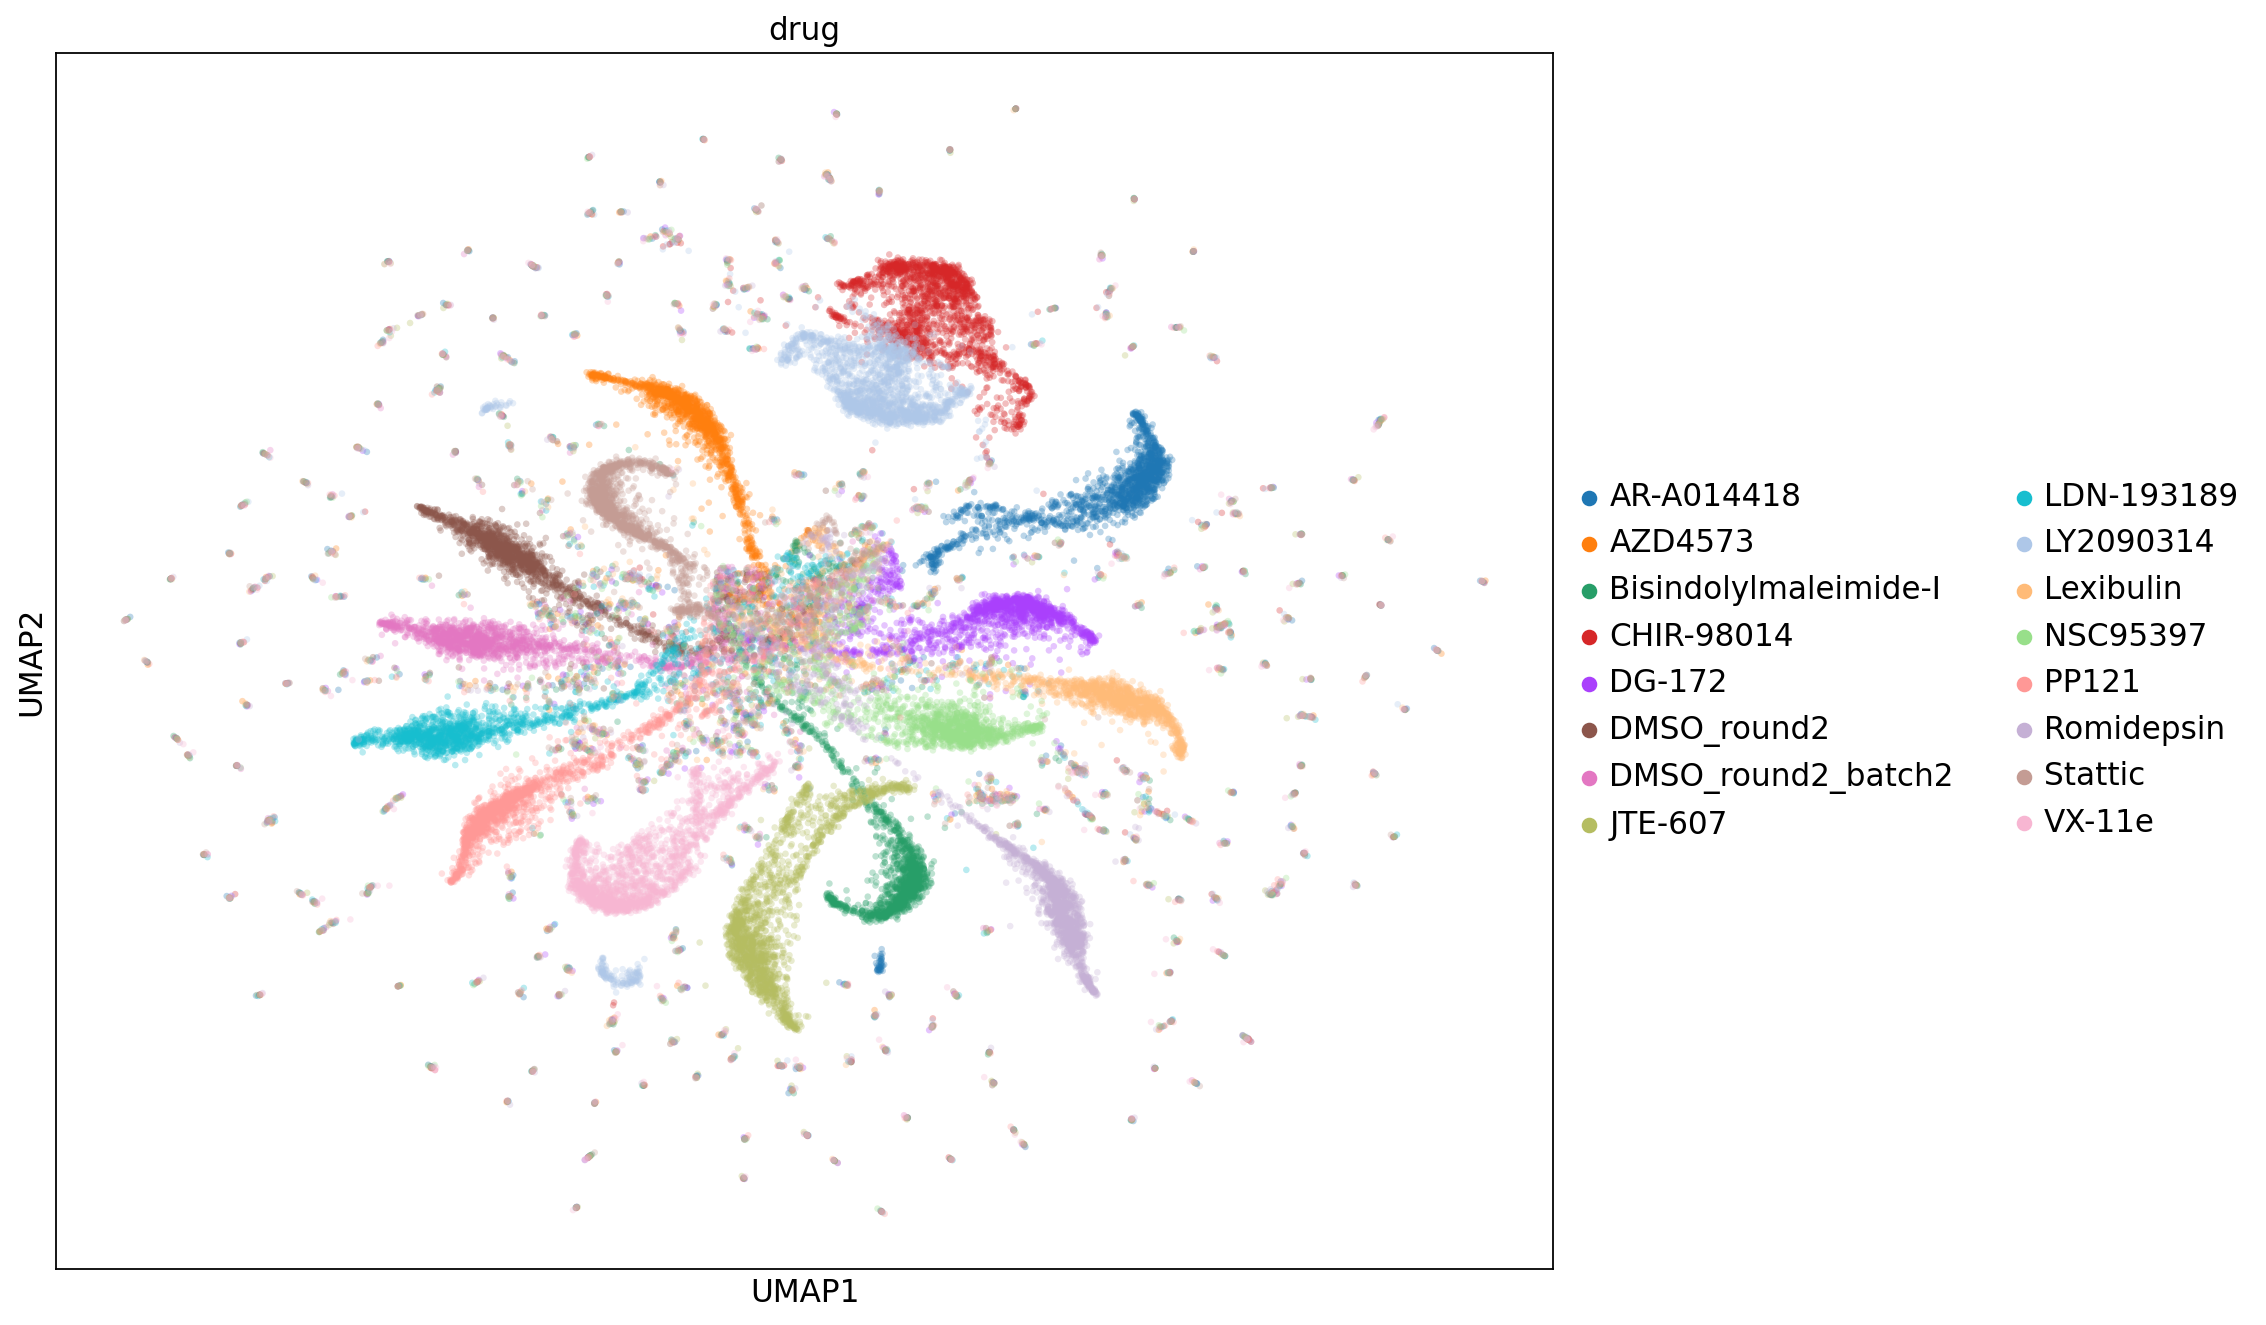

In [11]:
# Reset all figure parameters to scanpy defaults
sc.set_figure_params(scanpy=True)
sc.settings.palette = None
adata.obs.drug=[x.replace('PosteriorMean_matrix_', '') for x in adata.obs.drug]
fig, ax = plt.subplots(figsize=(12, 10))

sc.pl.umap(adata, 
           color='drug',
           size=35,  
           alpha=0.3,
           legend_fontoutline=3, 
           #legend_loc = 'center',
           legend_fontsize=14,
           ax=ax,
           legend_fontweight='normal')

#plt.show()



In [12]:
# Assuming:
# - df_strength: DataFrame with drugs as columns, perturbations as rows, values = # of DE genes
# - adata: AnnData object with adata.obs['drug'] and adata.obs['gene']

def add_perturbation_strength(adata, df_strength):
    """
    Add perturbation strength from a dataframe to adata.obs
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with 'drug' and 'gene' columns in .obs
    df_strength : pd.DataFrame
        DataFrame with drugs as columns, genes/perturbations as rows
    
    Returns:
    --------
    None (modifies adata.obs in place)
    """
    
    # Method 1: Using apply (simple but slower)
    def lookup_strength(row):
        gene = row['gene']
        drug = row['drug']
        
        # Check if gene and drug exist in the dataframe
        if gene in df_strength.index and drug in df_strength.columns:
            return df_strength.loc[gene, drug]
        else:
            return np.nan
    
    adata.obs['perturbation_strength'] = adata.obs.apply(lookup_strength, axis=1)
    
    # Report statistics
    n_total = len(adata.obs)
    n_found = adata.obs['perturbation_strength'].notna().sum()
    print(f"Matched {n_found}/{n_total} ({n_found/n_total*100:.1f}%) perturbations")
    print(f"Missing values: {n_total - n_found}")
    
    return adata


# Usage:
adata = add_perturbation_strength(adata, perturbationStrength)

# Now you can use it:
# sc.pl.umap(adata, color='perturbation_strength', ...)

Matched 30704/30704 (100.0%) perturbations
Missing values: 0


In [12]:
# -----------------------------------------------------------
# Save the perturbation embeddings for downstream notebooks
# -----------------------------------------------------------
EMB_OUT_H5 = OUTPUT_DIR / 'perturbation_embeddings.h5ad'
PCA_CSV    = OUTPUT_DIR / 'X_pca.csv'
UMAP_CSV   = OUTPUT_DIR / 'X_umap.csv'

print(f'Saving full embeddings AnnData → {EMB_OUT_H5}')
adata.write_h5ad(EMB_OUT_H5, compression='gzip')
print(f'  size: {EMB_OUT_H5.stat().st_size / 1e9:.2f} GB')

# Lightweight CSVs for fast re-loading without scanpy
clean_index = [x.replace('PosteriorMean_matrix_', '') for x in adata.obs_names]

pd.DataFrame(
    adata.obsm['X_pca'],
    index=clean_index,
    columns=[f'PC{i+1}' for i in range(adata.obsm['X_pca'].shape[1])],
).rename_axis('drug__gene').to_csv(PCA_CSV)

pd.DataFrame(
    adata.obsm['X_umap'],
    index=clean_index,
    columns=['UMAP1', 'UMAP2'],
).rename_axis('drug__gene').to_csv(UMAP_CSV)

print(f'  PCA  → {PCA_CSV}')
print(f'  UMAP → {UMAP_CSV}')

Saving full embeddings AnnData → /home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/perturbation_embeddings.h5ad
  size: 3.12 GB
  PCA  → /home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/X_pca.csv
  UMAP → /home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/X_umap.csv


In [13]:
adata.obs["gene"].value_counts().value_counts()

count
16    1919
Name: count, dtype: int64

<Axes: title={'center': 'perturbation_strength'}, xlabel='UMAP1', ylabel='UMAP2'>

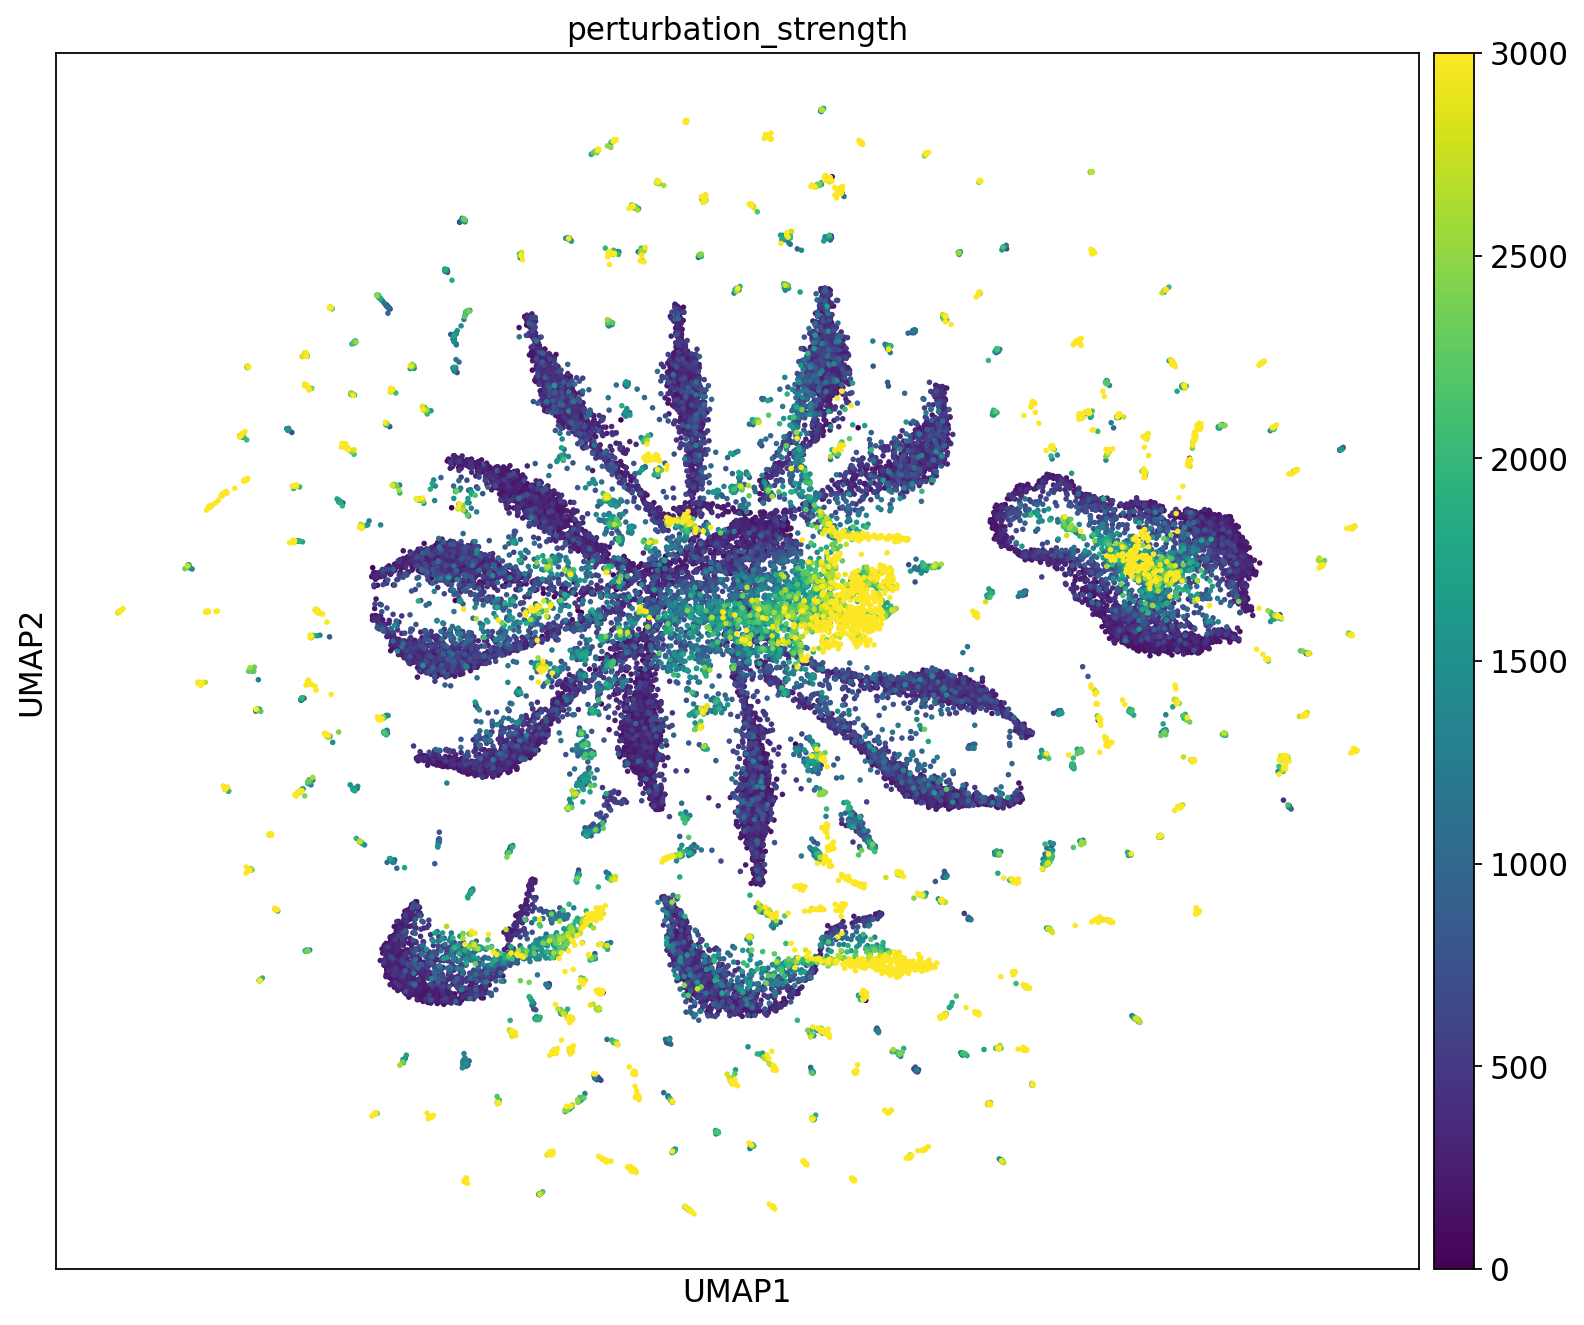

In [39]:
fig, ax = plt.subplots(figsize=(12, 10))

sc.pl.umap(adata, 
           color='perturbation_strength',
           size=25,  
           legend_fontoutline=3, 
           #legend_loc = 'center',
           legend_fontsize=14,
           vmax=3000,
           ax=ax,
           legend_fontweight='normal', show=False,)


In [41]:
adj_matrix = pd.DataFrame(adata.obsp['connectivities'].toarray())
adj_matrix.index=[x.replace('PosteriorMean_matrix_', '') for x in adata.obs.index]
adj_matrix.columns=adj_matrix.index

In [42]:
adj_matrix_dist = pd.DataFrame(adata.obsp['distances'].toarray())
adj_matrix_dist.index=[x.replace('PosteriorMean_matrix_', '') for x in adata.obs.index]
adj_matrix_dist.columns=adj_matrix_dist.index

In [43]:
adj_matrix_dist

,AR-A014418::A1BG,AR-A014418::AASS,AR-A014418::ABCB6,AR-A014418::ABCC5,AR-A014418::ABCF3,AR-A014418::ABHD4,AR-A014418::ABL1,AR-A014418::ACAA1,AR-A014418::ACAT2,AR-A014418::ACBD3,...,VX-11e::ZNF91,VX-11e::ZNF93,VX-11e::ZRSR2,VX-11e::ZSCAN10,VX-11e::ZSCAN2,VX-11e::ZSCAN21,VX-11e::ZSCAN32,VX-11e::ZW10,VX-11e::ZXDC,VX-11e::ZZZ3
AR-A014418::A1BG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR-A014418::AASS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR-A014418::ABCB6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR-A014418::ABCC5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR-A014418::ABCF3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VX-11e::ZSCAN21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VX-11e::ZSCAN32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VX-11e::ZW10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VX-11e::ZXDC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total perturbations: 30704
Unique drugs: 16
Unique genes: 1919
Processing 0/30704...
Processing 100/30704...
Processing 200/30704...
Processing 300/30704...
Processing 400/30704...
Processing 500/30704...
Processing 600/30704...
Processing 700/30704...
Processing 800/30704...
Processing 900/30704...
Processing 1000/30704...
Processing 1100/30704...
Processing 1200/30704...
Processing 1300/30704...
Processing 1400/30704...
Processing 1500/30704...
Processing 1600/30704...
Processing 1700/30704...
Processing 1800/30704...
Processing 1900/30704...
Processing 2000/30704...
Processing 2100/30704...
Processing 2200/30704...
Processing 2300/30704...
Processing 2400/30704...
Processing 2500/30704...
Processing 2600/30704...
Processing 2700/30704...
Processing 2800/30704...
Processing 2900/30704...
Processing 3000/30704...
Processing 3100/30704...
Processing 3200/30704...
Processing 3300/30704...
Processing 3400/30704...
Processing 3500/30704...
Processing 3600/30704...
Processing 3700/30704...

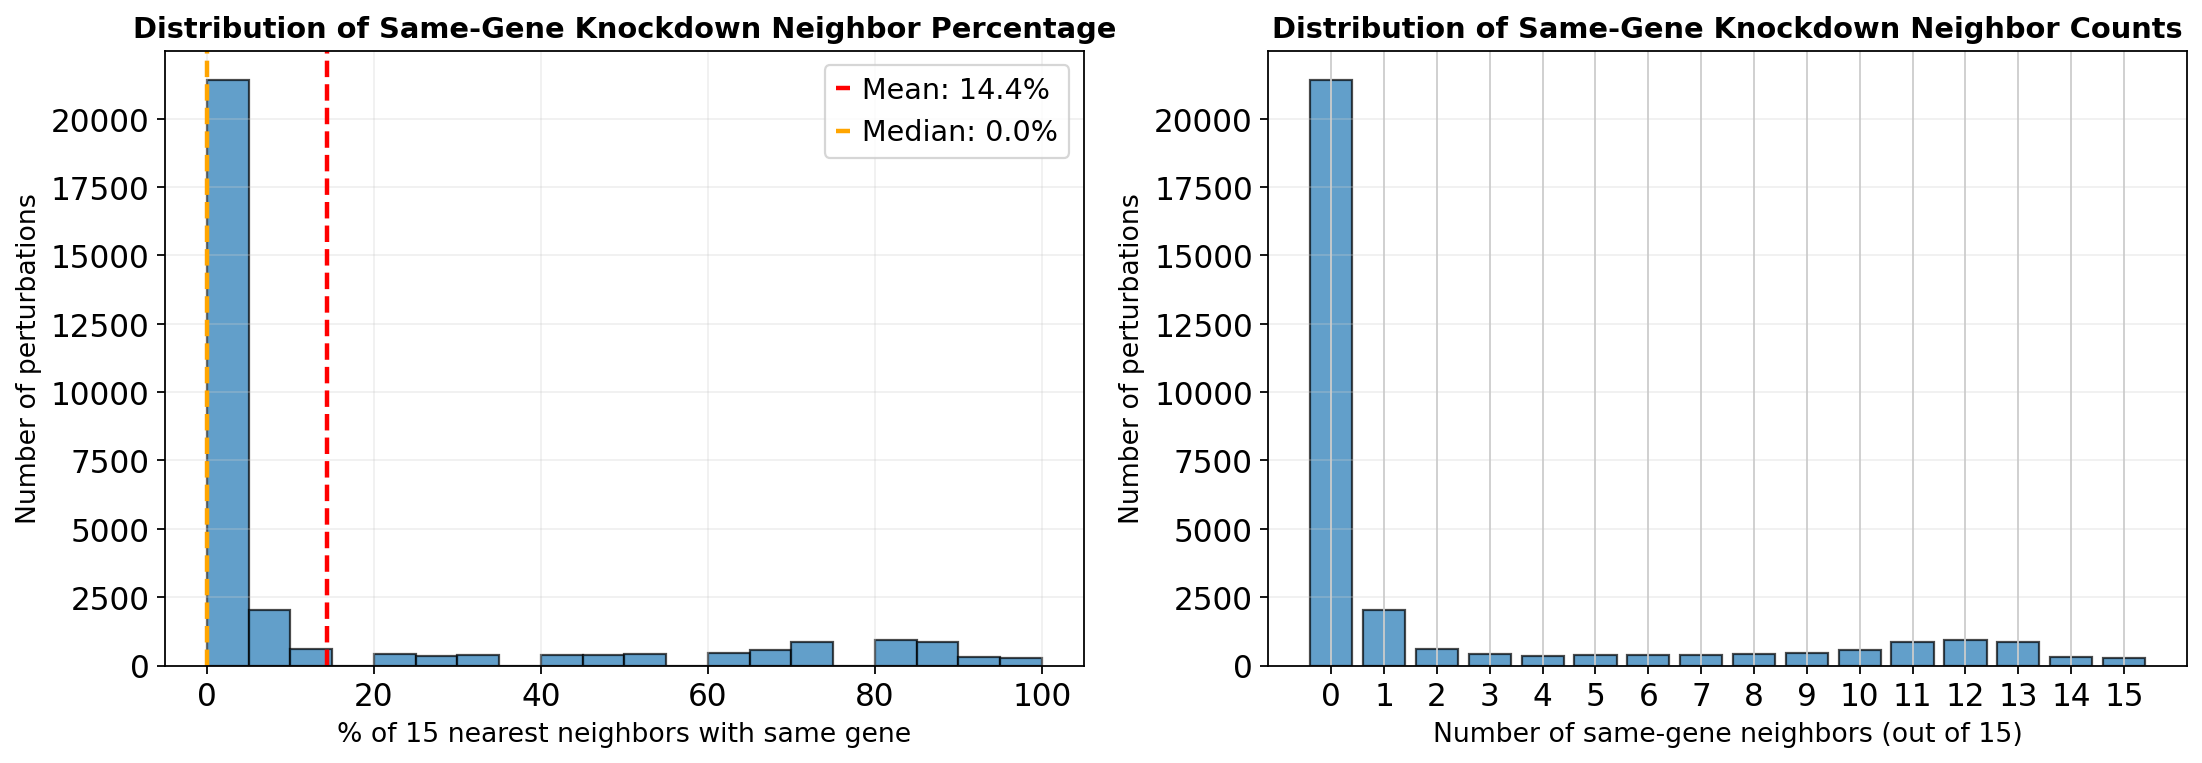

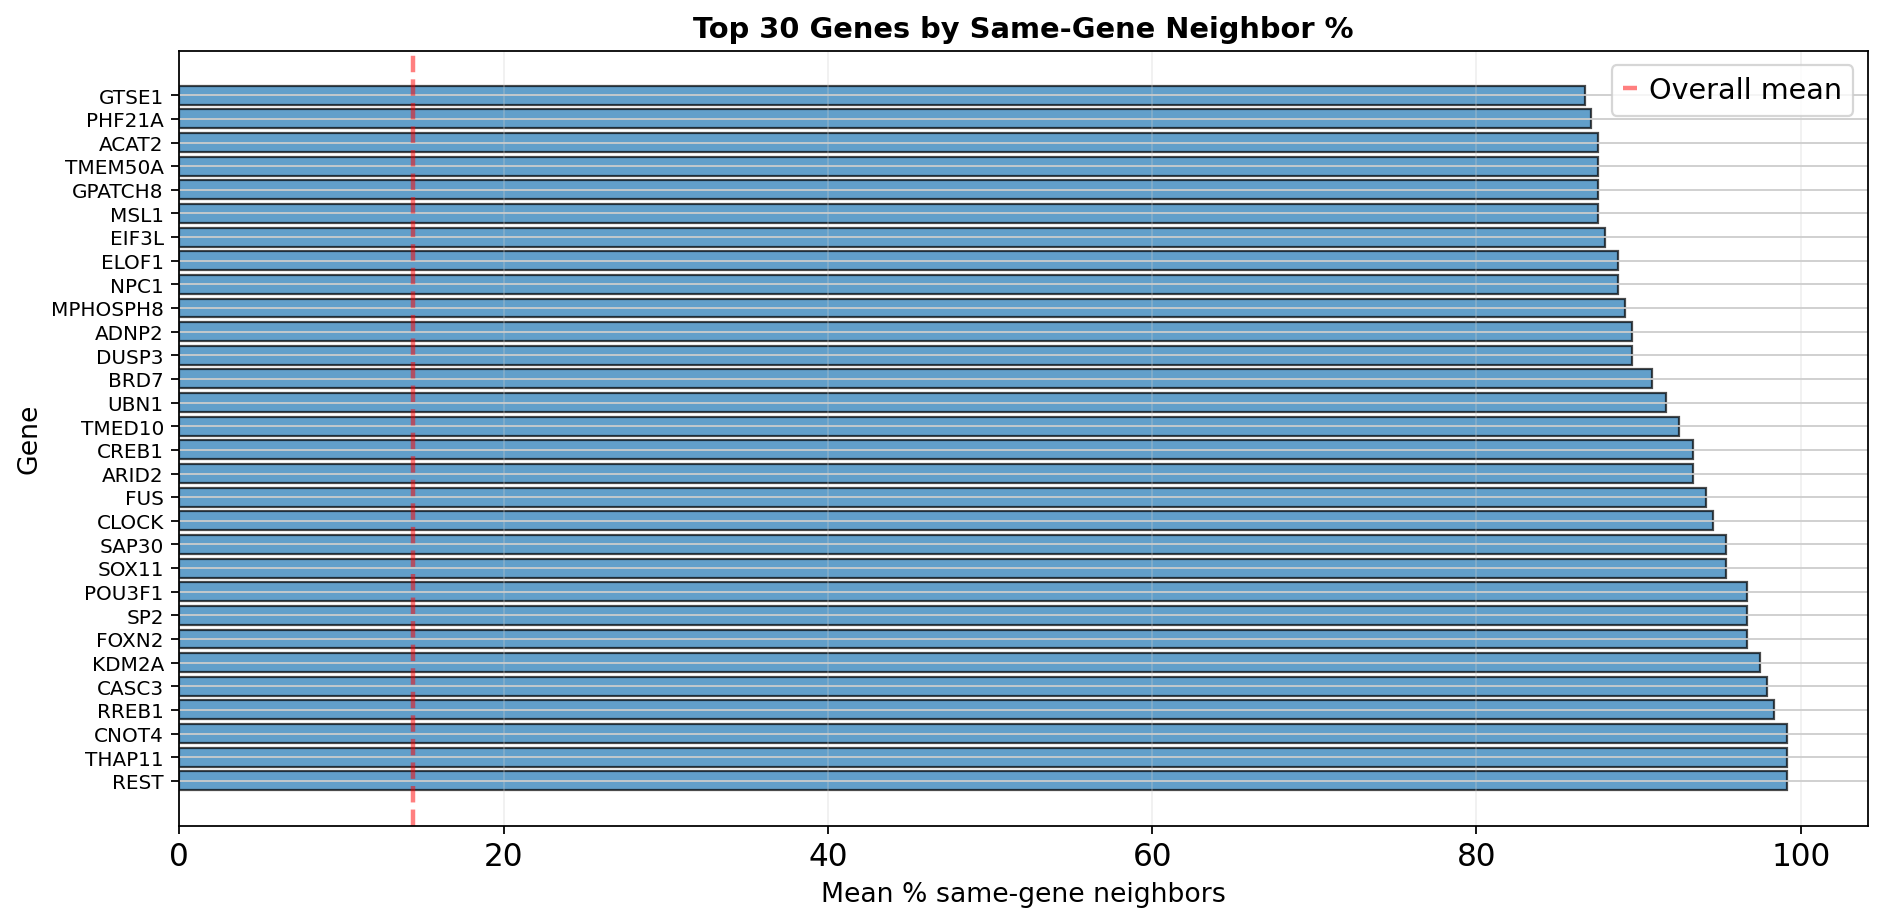


Genes with highest same-gene concordance:
gene
REST      99.166667
THAP11    99.166667
CNOT4     99.166667
RREB1     98.333333
CASC3     97.916667
KDM2A     97.500000
FOXN2     96.666667
SP2       96.666667
POU3F1    96.666667
SOX11     95.416667
Name: pct_same_gene, dtype: float64

Genes with lowest same-gene concordance:
gene
PLK2         0.0
ID2          0.0
IDE          0.0
IER3         0.0
PPIB         0.0
PPIC         0.0
TNFRSF12A    0.0
IL17RC       0.0
IL4R         0.0
ING2         0.0
Name: pct_same_gene, dtype: float64


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_gene_neighbor_concordance(adjacency_matrix, k=15):
    """
    Analyze how many of the k nearest neighbors share the same genetic perturbation.
    
    Parameters:
    -----------
    adjacency_matrix : pd.DataFrame or np.ndarray
        Adjacency matrix with row/column names like "Drug::Gene"
    k : int
        Number of nearest neighbors to consider
    
    Returns:
    --------
    results : pd.DataFrame
        DataFrame with columns: perturbation, gene, drug, n_same_gene, pct_same_gene
    """
    
    # Convert to DataFrame if numpy array
    if isinstance(adjacency_matrix, np.ndarray):
        raise ValueError("Please provide a pandas DataFrame with index/column names")
    
    adj = adjacency_matrix.copy()
    
    # Parse perturbation names to extract drug and gene
    def parse_name(name):
        parts = name.split('::')
        if len(parts) == 2:
            return parts[0], parts[1]  # drug, gene
        else:
            return None, None
    
    # Extract drug and gene for all perturbations
    index_info = pd.DataFrame([parse_name(name) for name in adj.index], 
                               columns=['drug', 'gene'],
                               index=adj.index)
    
    print(f"Total perturbations: {len(adj)}")
    print(f"Unique drugs: {index_info['drug'].nunique()}")
    print(f"Unique genes: {index_info['gene'].nunique()}")
    
    results = []
    
    # For each perturbation (row)
    for i, pert_name in enumerate(adj.index):
        if i % 100 == 0:
            print(f"Processing {i}/{len(adj)}...")
        
        # Get this perturbation's info
        drug = index_info.loc[pert_name, 'drug']
        gene = index_info.loc[pert_name, 'gene']
        
        # Get adjacency values for this row (exclude self)
        adj_values = adj.loc[pert_name, :].copy()
        adj_values[pert_name] = -np.inf  # Exclude self from neighbors
        
        # Get k nearest neighbors (highest adjacency values)
        neighbor_indices = adj_values.nlargest(k).index
        
        # Count how many neighbors have the same gene
        neighbor_genes = index_info.loc[neighbor_indices, 'gene']
        n_same_gene = (neighbor_genes == gene).sum()
        pct_same_gene = (n_same_gene / k) * 100
        
        results.append({
            'perturbation': pert_name,
            'gene': gene,
            'drug': drug,
            'n_same_gene': n_same_gene,
            'pct_same_gene': pct_same_gene
        })
    
    results_df = pd.DataFrame(results)
    
    # Print summary statistics
    print("\n" + "="*60)
    print("Summary Statistics:")
    print("="*60)
    print(f"Mean % same-gene neighbors: {results_df['pct_same_gene'].mean():.1f}%")
    print(f"Median % same-gene neighbors: {results_df['pct_same_gene'].median():.1f}%")
    print(f"Std % same-gene neighbors: {results_df['pct_same_gene'].std():.1f}%")
    print(f"\nDistribution of same-gene neighbor counts:")
    print(results_df['n_same_gene'].value_counts().sort_index())
    
    return results_df


def plot_gene_concordance_distribution(results_df, k=10):
    """
    Plot the distribution of same-gene neighbor percentages.
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of percentages
    axes[0].hist(results_df['pct_same_gene'], bins=np.arange(0, 105, 5), 
                 edgecolor='black', alpha=0.7)
    axes[0].axvline(results_df['pct_same_gene'].mean(), 
                    color='red', linestyle='--', linewidth=2, 
                    label=f"Mean: {results_df['pct_same_gene'].mean():.1f}%")
    axes[0].axvline(results_df['pct_same_gene'].median(), 
                    color='orange', linestyle='--', linewidth=2,
                    label=f"Median: {results_df['pct_same_gene'].median():.1f}%")
    axes[0].set_xlabel(f'% of {k} nearest neighbors with same gene', fontsize=12)
    axes[0].set_ylabel('Number of perturbations', fontsize=12)
    axes[0].set_title('Distribution of Same-Gene Knockdown Neighbor Percentage', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Bar plot of counts
    count_dist = results_df['n_same_gene'].value_counts().sort_index()
    axes[1].bar(count_dist.index, count_dist.values, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel(f'Number of same-gene neighbors (out of {k})', fontsize=12)
    axes[1].set_ylabel('Number of perturbations', fontsize=12)
    axes[1].set_title('Distribution of Same-Gene Knockdown Neighbor Counts', fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(0, k+1))
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Additional plot: Per-gene analysis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    gene_means = results_df.groupby('gene')['pct_same_gene'].agg(['mean', 'count'])
    gene_means = gene_means[gene_means['count'] >= 5].sort_values('mean', ascending=False)
    
    # Plot top 30 genes
    top_genes = gene_means.head(30)
    ax.barh(range(len(top_genes)), top_genes['mean'], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_genes)))
    ax.set_yticklabels(top_genes.index, fontsize=9)
    ax.set_xlabel('Mean % same-gene neighbors', fontsize=12)
    ax.set_ylabel('Gene', fontsize=12)
    ax.set_title('Top 30 Genes by Same-Gene Neighbor %', fontsize=13, fontweight='bold')
    ax.axvline(results_df['pct_same_gene'].mean(), color='red', linestyle='--', 
               linewidth=2, alpha=0.5, label='Overall mean')
    ax.legend()
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


# ============================================================
# Usage
# ============================================================

# Load your adjacency matrix (assuming it's already a DataFrame)
# adj_matrix should have index and columns with names like "AR-A014418::STRAP"

# Analyze
results = analyze_gene_neighbor_concordance(adj_matrix, k=15)

# Plot
plot_gene_concordance_distribution(results, k=15)

# Save results
results.to_csv(OUTPUT_DIR / 'gene_neighbor_concordance.csv', index=False)

# Additional analyses
print("\nGenes with highest same-gene concordance:")
print(results.groupby('gene')['pct_same_gene'].mean().sort_values(ascending=False).head(10))

print("\nGenes with lowest same-gene concordance:")
print(results.groupby('gene')['pct_same_gene'].mean().sort_values(ascending=True).head(10))

Found 16 unique drugs


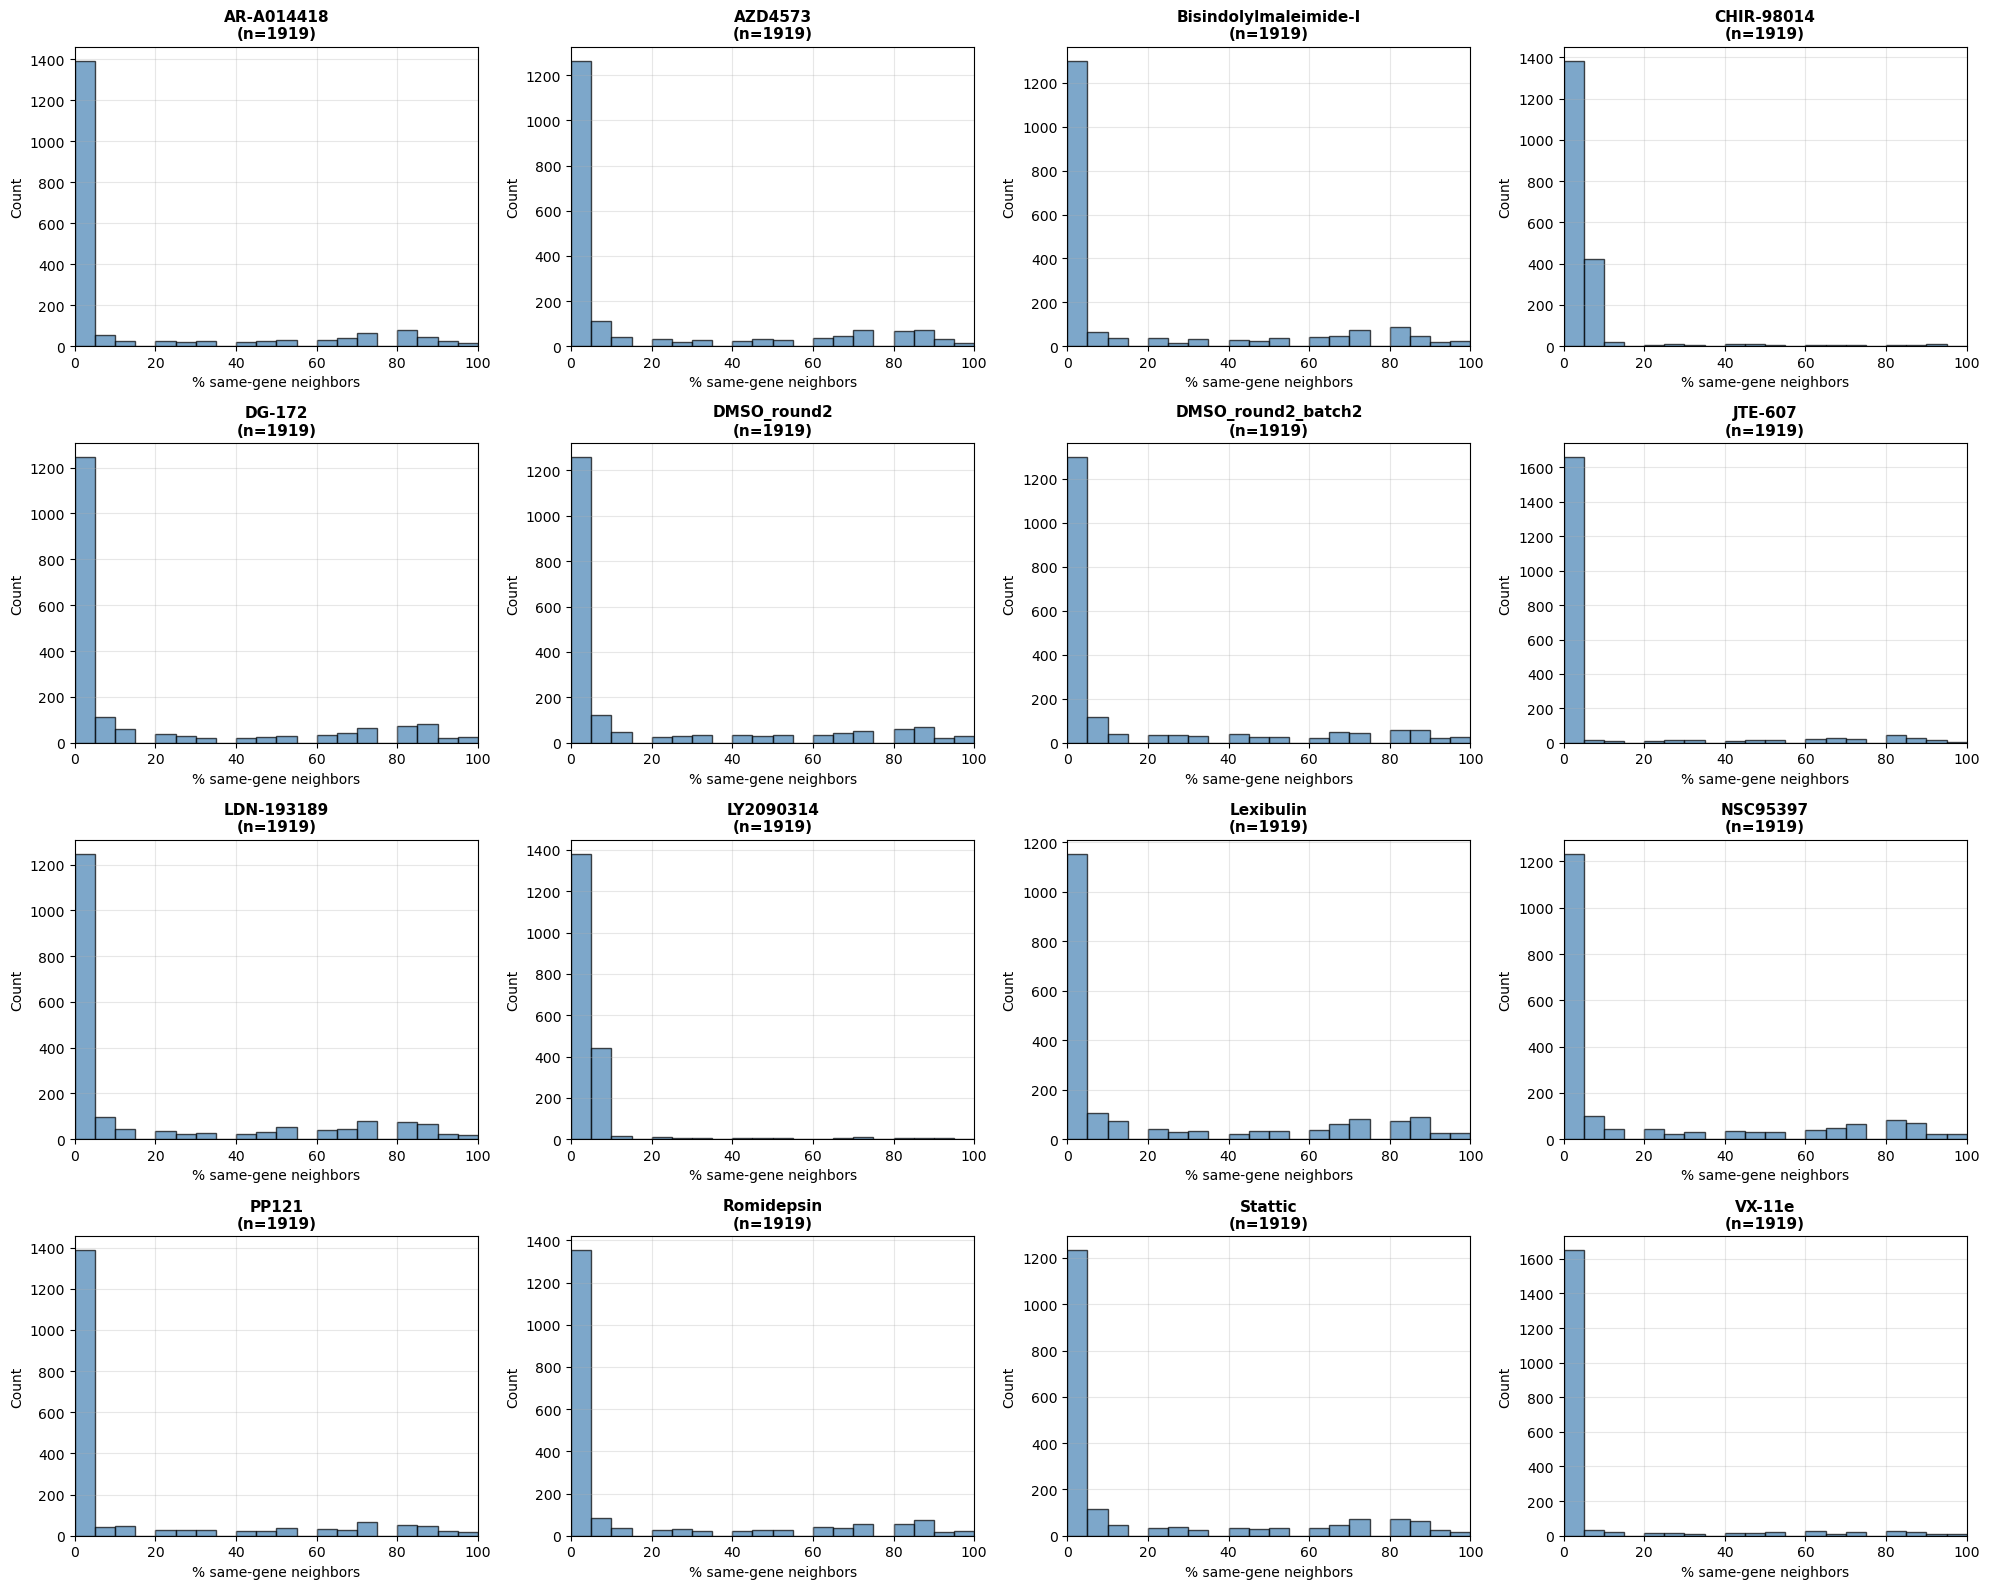

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the results
results = pd.read_csv(OUTPUT_DIR / 'gene_neighbor_concordance.csv')

# Get unique drugs
drugs = results['drug'].unique()
n_drugs = len(drugs)

print(f"Found {n_drugs} unique drugs")

# ============================================================
# Option 1: Grid of subplots (recommended for many drugs)
# ============================================================

def plot_histograms_by_drug(results, bins=15):
    """
    Create a grid of histograms, one for each drug.
    """
    drugs = sorted(results['drug'].unique())
    n_drugs = len(drugs)

    # Calculate grid dimensions
    n_cols = min(4, n_drugs)  # Max 4 columns
    n_rows = int(np.ceil(n_drugs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

    # Flatten axes array for easy iteration
    if n_drugs == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_drugs > 1 else [axes]

    for idx, drug in enumerate(drugs):
        ax = axes[idx]

        # Get data for this drug
        drug_data = results[results['drug'] == drug]['pct_same_gene']

        # Plot histogram
        ax.hist(drug_data, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')

        # Labels and title
        ax.set_xlabel('% same-gene neighbors', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{drug}\n(n={len(drug_data)})', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 100)

    # Hide empty subplots
    for idx in range(n_drugs, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'pct_same_gene_by_drug_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_histograms_by_drug(results, bins=20)


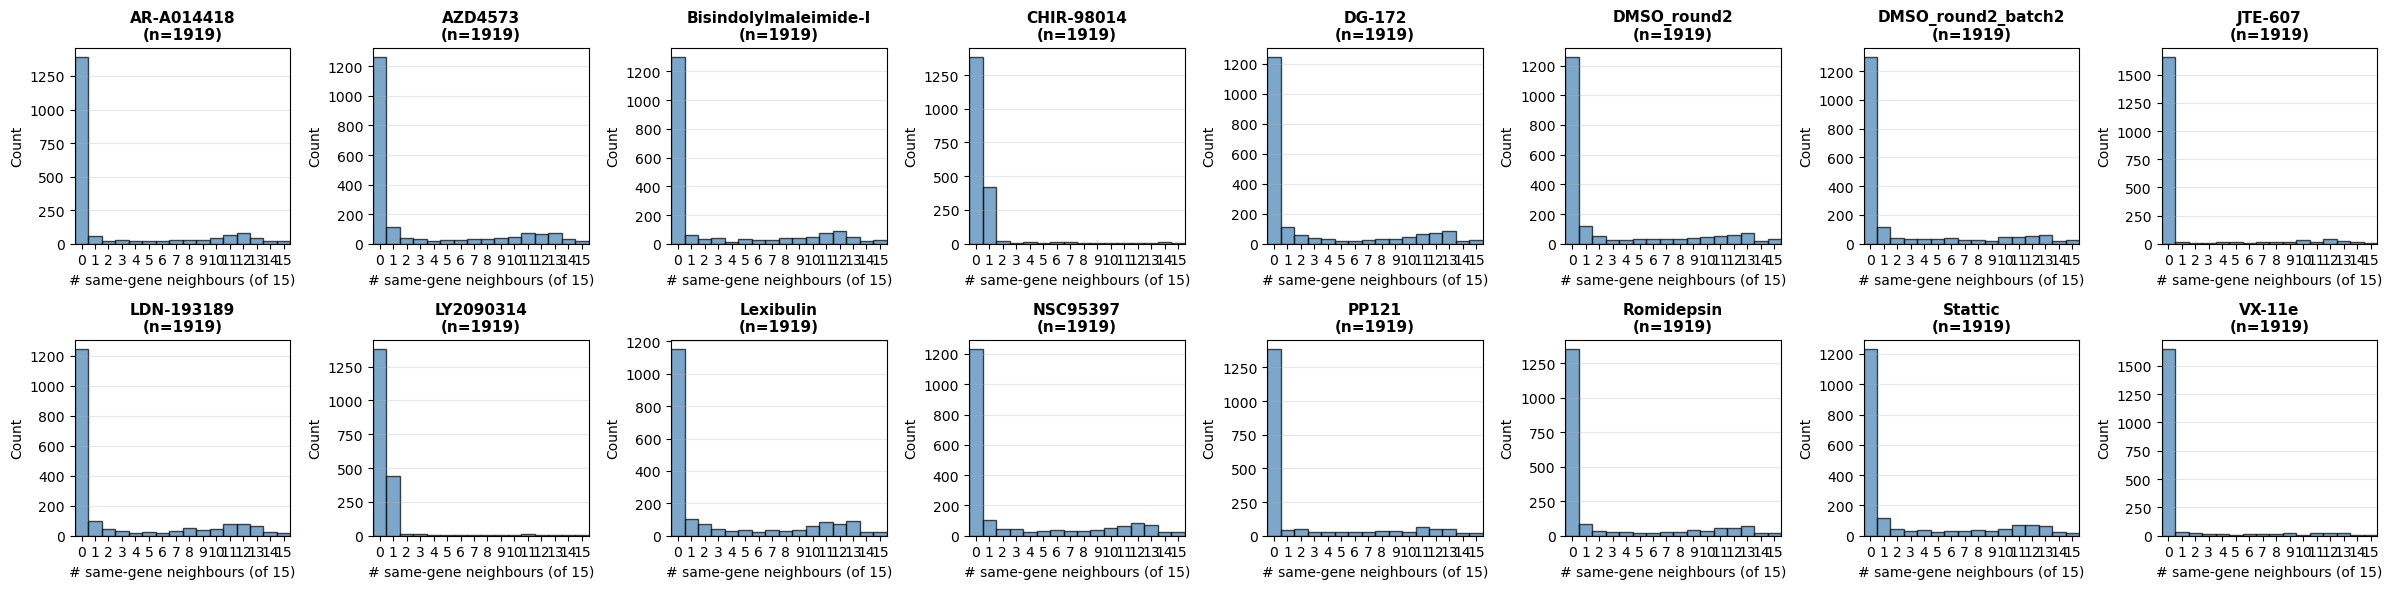

In [12]:
# Generic helper: pull objects from kernel scope, else load from saved files,
# else fall back to a "build" function that derives them from earlier outputs.
import scanpy as sc
import pickle

def _ensure(name, *, csv=None, h5ad=None, pickle_path=None, build=None,
            require_columns=None, _ns=None):
    """Return a cached object: prefer in-scope variable, else read from
    the given file, else call ``build()`` to derive it. ``_ns`` is the
    namespace to inspect (typically ``globals()``)."""
    obj = _ns.get(name)
    if obj is not None:
        if require_columns and not all(c in obj.columns for c in require_columns):
            obj = None
    if obj is not None:
        return obj
    if csv is not None and Path(csv).exists():
        print(f'Loading {name} ← {csv}')
        return pd.read_csv(csv)
    if h5ad is not None and Path(h5ad).exists():
        print(f'Loading {name} ← {h5ad}')
        return sc.read_h5ad(h5ad)
    if pickle_path is not None and Path(pickle_path).exists():
        print(f'Loading {name} ← {pickle_path}')
        with open(pickle_path, 'rb') as f:
            return pickle.load(f)
    if build is not None:
        print(f'Building {name} from upstream objects')
        return build()
    raise FileNotFoundError(
        f'Could not resolve `{name}` — not in scope and no saved file found '
        f'(csv={csv}, h5ad={h5ad})'
    )

# Resolve `adata` (perturbation embeddings AnnData)
adata = _ensure('adata',
                h5ad=OUTPUT_DIR / 'perturbation_embeddings.h5ad',
                _ns=globals())

# Resolve `adj_matrix` (drug__gene × drug__gene connectivities)
def _build_adj_matrix():
    df = pd.DataFrame(adata.obsp['connectivities'].toarray())
    df.index = [x.replace('PosteriorMean_matrix_', '') for x in adata.obs.index]
    df.columns = df.index
    return df

adj_matrix = _ensure('adj_matrix',
                      build=_build_adj_matrix,
                      _ns=globals())

# Resolve `results` (gene-neighbour concordance)
def _build_results():
    return analyze_gene_neighbor_concordance(adj_matrix, k=15)

results = _ensure('results',
                   csv=OUTPUT_DIR / 'gene_neighbor_concordance.csv',
                   build=_build_results,
                   require_columns=['drug', 'n_same_gene'],
                   _ns=globals())


def plot_count_histograms_by_drug(results, k=15):
    """Per-drug histogram of `n_same_gene` — the number of same-perturbation
    (same-gene) neighbours among each perturbation's k nearest neighbours.
    X-axis is integer count in [0, k]."""
    drugs = sorted(results['drug'].unique())
    n_drugs = len(drugs)

    n_cols = 8
    n_rows = int(np.ceil(n_drugs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten() if n_drugs > 1 else [axes]

    bins = np.arange(0, k + 2) - 0.5    # integer-aligned bins 0..k

    for idx, drug in enumerate(drugs):
        ax = axes[idx]
        drug_data = results[results['drug'] == drug]['n_same_gene']
        ax.hist(drug_data, bins=bins, edgecolor='black',
                alpha=0.7, color='steelblue')
        ax.set_xlabel(f'# same-gene neighbours (of {k})', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{drug}\n(n={len(drug_data)})',
                     fontsize=11, fontweight='bold')
        ax.set_xticks(np.arange(0, k + 1))
        ax.set_xlim(-0.5, k + 0.5)
        ax.grid(alpha=0.3, axis='y')

    for idx in range(n_drugs, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'n_same_gene_by_drug_histograms.png',
                dpi=300, bbox_inches='tight')
    plt.show()


plot_count_histograms_by_drug(results, k=15)


In [55]:
# Same-drug neighbour concordance: of each perturbation's 15 nearest
# neighbours, how many are perts from the SAME drug context (regardless of
# which gene)?  High % here means the embedding is dominated by drug-context
# rather than KO biology.

def analyze_drug_neighbor_concordance(adjacency_matrix, k=15):
    if isinstance(adjacency_matrix, np.ndarray):
        raise ValueError("Please provide a pandas DataFrame with index/column names")

    adj = adjacency_matrix.copy()

    def parse_name(name):
        parts = name.split('::')
        return (parts[0], parts[1]) if len(parts) == 2 else (None, None)

    index_info = pd.DataFrame(
        [parse_name(name) for name in adj.index],
        columns=['drug', 'gene'],
        index=adj.index,
    )

    print(f"Total perturbations: {len(adj)}")
    print(f"Unique drugs: {index_info['drug'].nunique()}")
    print(f"Unique genes: {index_info['gene'].nunique()}")

    results = []
    for i, pert_name in enumerate(adj.index):
        if i % 1000 == 0:
            print(f"Processing {i}/{len(adj)}...")
        drug = index_info.loc[pert_name, 'drug']
        gene = index_info.loc[pert_name, 'gene']

        adj_values = adj.loc[pert_name, :].copy()
        adj_values[pert_name] = -np.inf      # exclude self
        neighbor_indices = adj_values.nlargest(k).index

        neighbor_drugs = index_info.loc[neighbor_indices, 'drug']
        n_same_drug = (neighbor_drugs == drug).sum()
        pct_same_drug = (n_same_drug / k) * 100

        results.append({
            'perturbation':  pert_name,
            'drug':          drug,
            'gene':          gene,
            'n_same_drug':   int(n_same_drug),
            'pct_same_drug': float(pct_same_drug),
        })

    results_df = pd.DataFrame(results)
    print()
    print('=' * 60)
    print('Summary statistics:')
    print('=' * 60)
    print(f"Mean   % same-drug neighbours: {results_df['pct_same_drug'].mean():.1f}%")
    print(f"Median % same-drug neighbours: {results_df['pct_same_drug'].median():.1f}%")
    print(f"Std    % same-drug neighbours: {results_df['pct_same_drug'].std():.1f}%")
    return results_df


drug_concordance = analyze_drug_neighbor_concordance(adj_matrix, k=15)
drug_concordance.to_csv(OUTPUT_DIR / 'drug_neighbor_concordance.csv', index=False)
print(f"\nSaved → {OUTPUT_DIR / 'drug_neighbor_concordance.csv'}")


Total perturbations: 30704
Unique drugs: 16
Unique genes: 1919
Processing 0/30704...
Processing 1000/30704...
Processing 2000/30704...
Processing 3000/30704...
Processing 4000/30704...
Processing 5000/30704...
Processing 6000/30704...
Processing 7000/30704...
Processing 8000/30704...
Processing 9000/30704...
Processing 10000/30704...
Processing 11000/30704...
Processing 12000/30704...
Processing 13000/30704...
Processing 14000/30704...
Processing 15000/30704...
Processing 16000/30704...
Processing 17000/30704...
Processing 18000/30704...
Processing 19000/30704...
Processing 20000/30704...
Processing 21000/30704...
Processing 22000/30704...
Processing 23000/30704...
Processing 24000/30704...
Processing 25000/30704...
Processing 26000/30704...
Processing 27000/30704...
Processing 28000/30704...
Processing 29000/30704...
Processing 30000/30704...

Summary statistics:
Mean   % same-drug neighbours: 79.7%
Median % same-drug neighbours: 100.0%
Std    % same-drug neighbours: 33.3%

Saved → /h

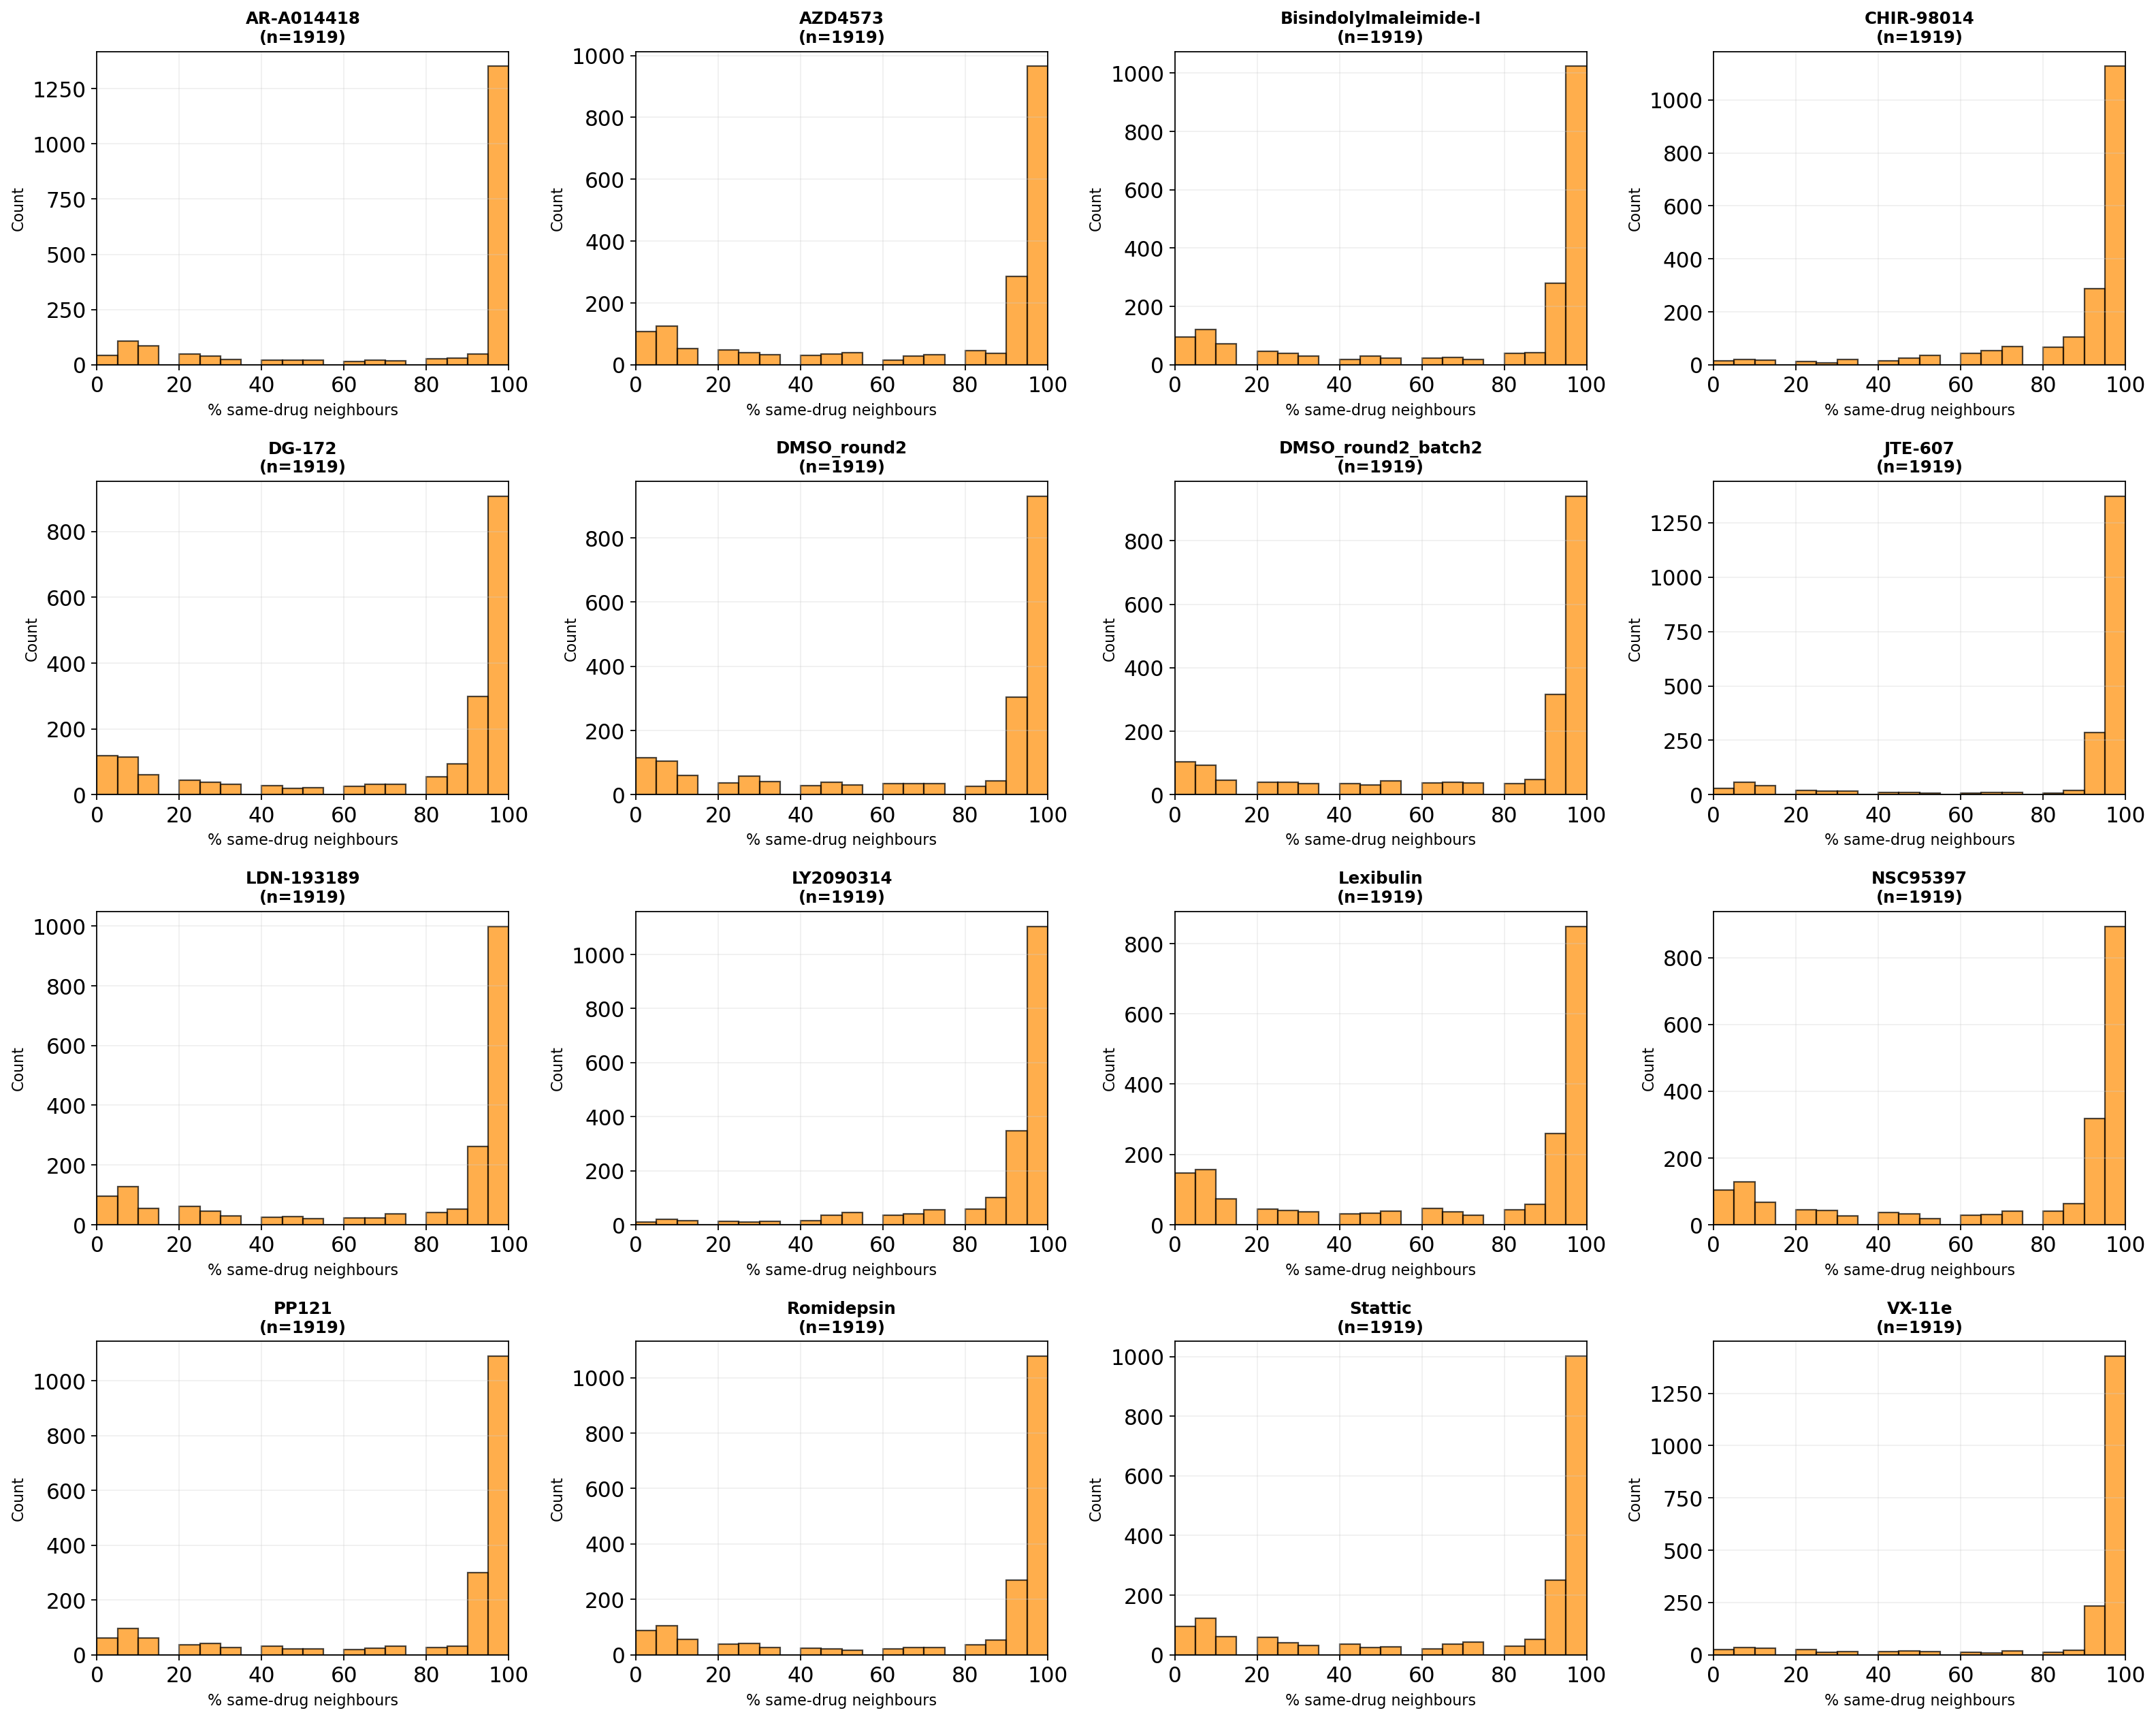

In [56]:
# Per-drug histograms of "% of 15 nearest neighbours that are from the
# SAME drug context".

def plot_same_drug_histograms_by_drug(results, bins=20):
    drugs = sorted(results['drug'].unique())
    n_drugs = len(drugs)
    n_cols = min(4, n_drugs)
    n_rows = int(np.ceil(n_drugs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_drugs > 1 else [axes]

    for idx, drug in enumerate(drugs):
        ax = axes[idx]
        drug_data = results[results['drug'] == drug]['pct_same_drug']
        ax.hist(drug_data, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
        ax.set_xlabel('% same-drug neighbours', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{drug}\n(n={len(drug_data)})', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 100)

    for idx in range(n_drugs, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'pct_same_drug_by_drug_histograms.png',
                dpi=300, bbox_inches='tight')
    plt.show()


plot_same_drug_histograms_by_drug(drug_concordance, bins=20)


{'drug_a': 'DMSO_round2', 'drug_b': 'DMSO_round2_batch2', 'n_rows_drug_a': 1919, 'n_with_batch2_counterpart_present': 1919, 'n_with_batch2_counterpart_in_topk': 560, 'fraction_in_topk_among_present': 0.2918186555497655, 'n_rank1': 352, 'fraction_rank1_among_present': 0.18342886920270973}


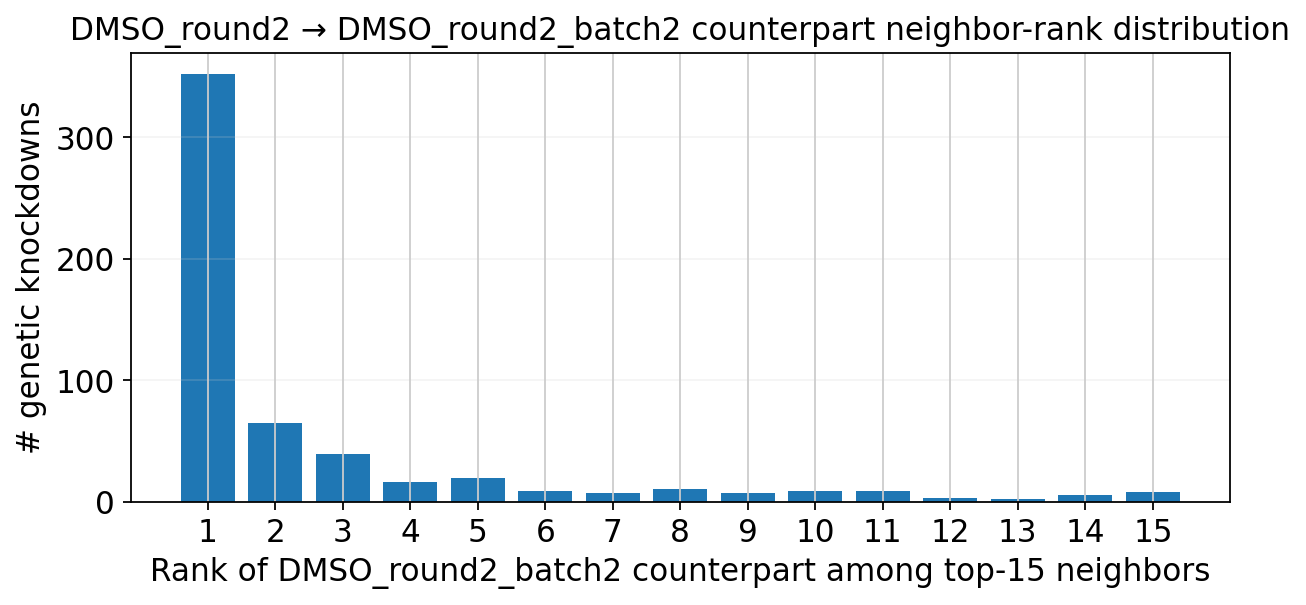

missing_target: 0
not_in_topk:    1359


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def batch2_rank_distribution(
    drug_a,
    drug_b,
    dist_df: pd.DataFrame,
    sep: str = "::",
    max_rank: int = 30
):
    """
    For each row drug_a::pert, find the rank (1..max_rank) of drug_b::pert
    among the nonzero neighbor distances (smaller = closer).
    Returns:
      summary dict
      per-perturbation DataFrame with rank info
      rank_counts Series indexed by rank (1..max_rank) plus 'not_in_topk' and 'missing_target'
    """
    if not dist_df.index.equals(dist_df.columns):
        raise ValueError("dist_df must be square with identical index and columns ordering.")

    rows_a = [s for s in dist_df.index.astype(str) if s.startswith(f"{drug_a}{sep}")]
    if len(rows_a) == 0:
        raise ValueError(f"No rows found for drug_a={drug_a} using sep='{sep}'")

    results = []
    for row in rows_a:
        pert = row.split(sep, 1)[1]
        target = f"{drug_b}{sep}{pert}"

        if target not in dist_df.columns:
            results.append({
                "row": row,
                "perturbation": pert,
                "target": target,
                "target_present": False,
                "target_rank": np.nan,
                "n_neighbors_listed": 0,
            })
            continue

        s = dist_df.loc[row]

        # listed neighbors: nonzero & finite
        neigh = s[(s != 0) & np.isfinite(s)]
        neigh = neigh.drop(index=row, errors="ignore")  # in case diagonal got included

        if neigh.empty:
            results.append({
                "row": row,
                "perturbation": pert,
                "target": target,
                "target_present": True,
                "target_rank": np.nan,
                "n_neighbors_listed": 0,
            })
            continue

        # rank neighbors by distance (ascending). If ties exist, this uses a stable order.
        neigh_sorted = neigh.sort_values(ascending=True)

        if target in neigh_sorted.index:
            rank = int(np.where(neigh_sorted.index.to_numpy() == target)[0][0]) + 1  # 1-based
            if rank > max_rank:
                rank = np.nan  # shouldn't happen if your list is top-k, but keep safe
        else:
            rank = np.nan

        results.append({
            "row": row,
            "perturbation": pert,
            "target": target,
            "target_present": True,
            "target_rank": rank,
            "n_neighbors_listed": int(len(neigh_sorted)),
        })

    res_df = pd.DataFrame(results)

    # Build rank counts
    rank_counts = pd.Series(0, index=list(range(1, max_rank + 1)) + ["not_in_topk", "missing_target"], dtype=int)

    rank_counts["missing_target"] = int((res_df["target_present"] == False).sum())
    in_topk = res_df["target_rank"].dropna().astype(int)
    for r, c in in_topk.value_counts().items():
        if 1 <= r <= max_rank:
            rank_counts[r] = int(c)

    rank_counts["not_in_topk"] = int(res_df["target_present"].sum() - in_topk.shape[0])

    summary = {
        "drug_a": drug_a,
        "drug_b": drug_b,
        "n_rows_drug_a": int(len(res_df)),
        "n_with_batch2_counterpart_present": int(res_df["target_present"].sum()),
        "n_with_batch2_counterpart_in_topk": int(in_topk.shape[0]),
        "fraction_in_topk_among_present": float(in_topk.shape[0] / res_df["target_present"].sum()) if res_df["target_present"].sum() else np.nan,
        "n_rank1": int(rank_counts[1]),
        "fraction_rank1_among_present": float(rank_counts[1] / res_df["target_present"].sum()) if res_df["target_present"].sum() else np.nan,
    }

    return summary, res_df, rank_counts


def plot_rank_counts(rank_counts: pd.Series,
                     drug_a="DMSO_round2", 
                     drug_b="DMSO_round2_batch2", max_rank: int = 15):
    """
    Bar plot: how often batch2 counterpart is rank 1, 2, ..., max_rank.
    """
    ranks = np.arange(1, max_rank + 1)
    counts = np.array([rank_counts.get(r, 0) for r in ranks], dtype=int)

    plt.figure(figsize=(8, 4))
    plt.bar(ranks, counts)
    plt.xticks(ranks)
    plt.xlabel(f"Rank of {drug_b} counterpart among top-{max_rank} neighbors")
    plt.ylabel("# genetic knockdowns")
    plt.title(f"{drug_a} → {drug_b} counterpart neighbor-rank distribution")
    plt.grid(alpha=0.2, axis="y")
    plt.tight_layout()
    plt.show()

    # Optional: report missing / not-in-topk
    print(f"missing_target: {int(rank_counts.get('missing_target', 0))}")
    print(f"not_in_topk:    {int(rank_counts.get('not_in_topk', 0))}")


# ---- Example usage ----b

summary, per_pert, rank_counts = batch2_rank_distribution(drug_a = "DMSO_round2",
                                                          drug_b = "DMSO_round2_batch2",
                                                          dist_df=adj_matrix_dist,
                                                          max_rank=30,
                                                         )
print(summary)
plot_rank_counts(rank_counts, max_rank=15)
per_pert.to_csv(OUTPUT_DIR / "dmso_batch2_rank_per_perturbation.csv", index=False)


{'drug_a': 'DMSO_round2_batch2', 'drug_b': 'DMSO_round2', 'n_rows_drug_a': 1919, 'n_with_batch2_counterpart_present': 1919, 'n_with_batch2_counterpart_in_topk': 529, 'fraction_in_topk_among_present': 0.2756644085461178, 'n_rank1': 370, 'fraction_rank1_among_present': 0.1928087545596665}


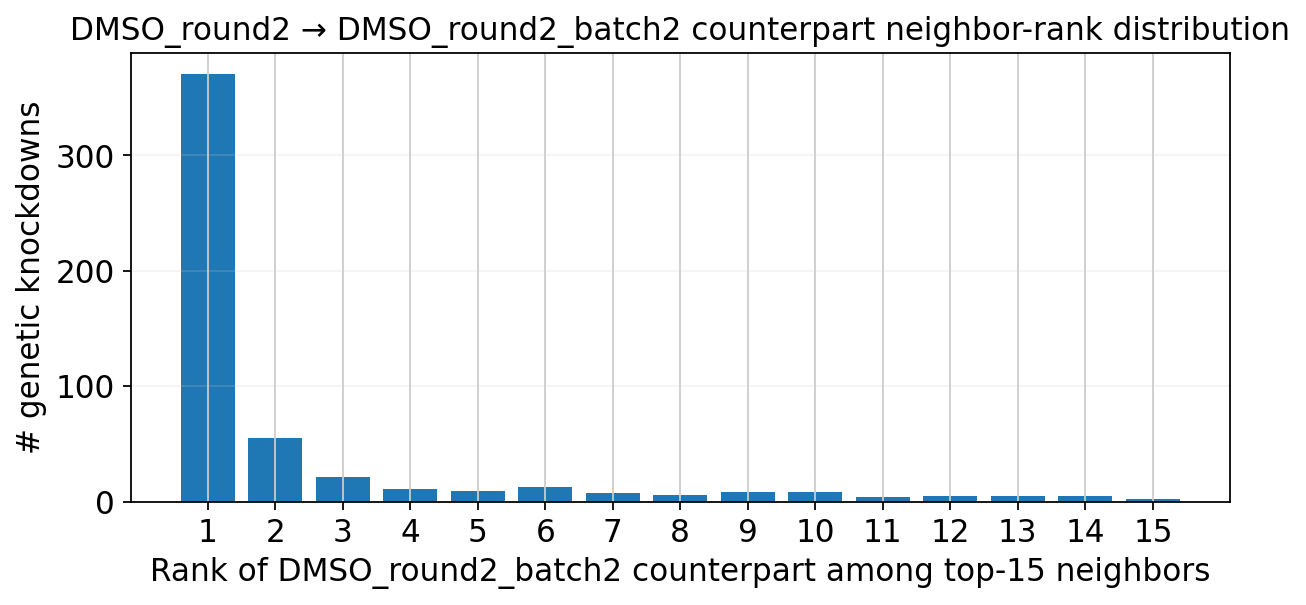

missing_target: 0
not_in_topk:    1390


In [51]:
summary, per_pert, rank_counts = batch2_rank_distribution(drug_b = "DMSO_round2",
                                                          drug_a = "DMSO_round2_batch2",
                                                          dist_df=adj_matrix_dist, max_rank=15,
                                                         )
print(summary)
plot_rank_counts(rank_counts, max_rank=15)



In [52]:
import numpy as np
import pandas as pd

def perts_whose_top15_lack_same_gene_other_context(
    dist_df: pd.DataFrame,
    sep: str = "::",
    k: int = 15,
    ignore_self: bool = True,
):
    """
    dist_df: square DataFrame with index/cols like 'drug::genetic_perturbation'
             Nonzero entries indicate the listed neighbors (top-k). Smaller = closer.

    Returns
    -------
    bad_list : list[str]
        Row labels (drug::gene) for which NONE of the listed top-k neighbors
        shares the same gene but in a different drug context.
    bad_details : pd.DataFrame
        Per-row diagnostics (how many same-gene neighbors found, etc.).
    """
    if not dist_df.index.equals(dist_df.columns):
        raise ValueError("dist_df must be square with identical index and columns ordering.")

    idx = dist_df.index.astype(str)

    # Pre-parse row labels -> (drug, gene)
    drugs = np.array([s.split(sep, 1)[0] for s in idx], dtype=object)
    genes = np.array([s.split(sep, 1)[1] for s in idx], dtype=object)

    bad = []
    rows = []

    for row_i, row_name in enumerate(idx):
        row_drug = drugs[row_i]
        row_gene = genes[row_i]

        s = dist_df.iloc[row_i]

        # neighbors are nonzero finite entries (as described)
        neigh = s[(s != 0) & np.isfinite(s)]
        if ignore_self:
            neigh = neigh.drop(index=row_name, errors="ignore")

        if neigh.empty:
            # no neighbors listed => definitely "bad" under this criterion
            bad.append(row_name)
            rows.append({
                "row": row_name,
                "row_drug": row_drug,
                "row_gene": row_gene,
                "n_neighbors_listed": 0,
                "n_same_gene_other_context": 0,
                "same_gene_other_context_neighbors": []
            })
            continue

        # if more than k entries exist, keep k closest
        neigh = neigh.sort_values().head(k)

        neigh_names = neigh.index.astype(str).to_numpy()
        neigh_drugs = np.array([n.split(sep, 1)[0] for n in neigh_names], dtype=object)
        neigh_genes = np.array([n.split(sep, 1)[1] for n in neigh_names], dtype=object)

        # "same genetic perturbation in a different drug context"
        mask_same_gene_other_context = (neigh_genes == row_gene) & (neigh_drugs != row_drug)

        same_gene_neighbors = neigh_names[mask_same_gene_other_context].tolist()
        n_same = int(mask_same_gene_other_context.sum())

        if n_same == 0:
            bad.append(row_name)

        rows.append({
            "row": row_name,
            "row_drug": row_drug,
            "row_gene": row_gene,
            "n_neighbors_listed": int(len(neigh)),
            "n_same_gene_other_context": n_same,
            "same_gene_other_context_neighbors": same_gene_neighbors
        })

    bad_details = pd.DataFrame(rows).sort_values(
        ["n_same_gene_other_context", "n_neighbors_listed", "row_drug", "row_gene"],
        ascending=[True, True, True, True]
    ).reset_index(drop=True)

    return bad, bad_details


# ---- Example usage ----
bad_list, bad_details = perts_whose_top15_lack_same_gene_other_context(adj_matrix_dist, k=15)
# print("N rows whose top-15 lacks same gene in other context:", len(bad_list))
bad_details.to_csv(OUTPUT_DIR / "no_same_gene_other_context_in_top15.csv", index=False)
bad_list[:10]


['AR-A014418::A1BG',
 'AR-A014418::AASS',
 'AR-A014418::ABCB6',
 'AR-A014418::ABCC5',
 'AR-A014418::ABCF3',
 'AR-A014418::ABHD4',
 'AR-A014418::ABL1',
 'AR-A014418::ACAA1',
 'AR-A014418::ACBD3',
 'AR-A014418::ACOT9']

In [58]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from pathlib import Path
import pickle

def compute_pairwise_explained_variance(
    folder_path,
    output_path=None,
    n_pcs=200,
    file_pattern="*.csv",
    selected_perts=None,
    selected_genes=None,
    orientation='genes_rows',  # 'genes_rows' or 'perts_rows'
    min_common_perts=50,
    min_common_genes=50
):
    """
    Compute pairwise explained variance between all matrix pairs in a folder.
    
    For each pair (X, Y):
    - Fit PCA on X with n_pcs components
    - Use X's PCs to predict Y via linear regression
    - Report R² (explained variance in Y)
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing matrix files
    output_path : str, optional
        Path to save results. If None, uses folder_path
    n_pcs : int
        Number of principal components to use (default: 200)
    file_pattern : str
        Pattern to match files (e.g., '*.csv', '*.tsv')
    selected_perts : list, optional
        List of perturbations to keep (filters rows or columns depending on orientation)
    selected_genes : list, optional
        List of genes to keep (filters columns or rows depending on orientation)
    orientation : str
        'genes_rows': genes are rows, perturbations are columns (will transpose for analysis)
        'perts_rows': perturbations are rows, genes are columns (default format)
    min_common_perts : int
        Minimum number of common perturbations required
    min_common_genes : int
        Minimum number of common genes required
    
    Returns:
    --------
    results : dict
        Dictionary containing explained variance matrices and metadata
    """
    
    folder = Path(folder_path)
    files = sorted(folder.glob(file_pattern))
    
    if len(files) == 0:
        raise ValueError(f"No files found matching pattern '{file_pattern}' in {folder_path}")
    
    # Create output directory
    if output_path is None:
        output_path = folder / 'explained_variance_results'
    else:
        output_path = Path(output_path)
    
    output_path.mkdir(exist_ok=True, parents=True)
    print(f"Results will be saved to: {output_path}")
    
    print(f"\nFound {len(files)} files to process")
    
    if selected_perts is not None:
        print(f"Filtering to {len(selected_perts)} selected perturbations")
    if selected_genes is not None:
        print(f"Filtering to {len(selected_genes)} selected genes")
    
    # Load and filter all matrices
    matrices = {}
    file_names = []
    
    for file_path in files:
        file_name = file_path.stem
        print(f"\nLoading: {file_name}")
        
        # Load data
        if file_path.suffix == '.csv':
            df = pd.read_csv(file_path, index_col=0)
        elif file_path.suffix == '.tsv':
            df = pd.read_csv(file_path, sep='\t', index_col=0)
        elif file_path.suffix == '.parquet':
            df = pd.read_parquet(file_path)
        else:
            raise ValueError(f"Unsupported file format: {file_path.suffix}")
        
        print(f"  Original shape: {df.shape}")
        
        # Apply filtering based on orientation
        if orientation == 'perts_rows':
            # Perturbations are rows, genes are columns
            if selected_perts is not None:
                valid_perts = df.index.intersection(selected_perts)
                df = df.loc[valid_perts, :]
                print(f"  After perturbation filtering: {df.shape[0]} perturbations")
            
            if selected_genes is not None:
                valid_genes = df.columns.intersection(selected_genes)
                df = df.loc[:, valid_genes]
                print(f"  After gene filtering: {df.shape[1]} genes")
                
        elif orientation == 'genes_rows':
            # Genes are rows, perturbations are columns
            if selected_genes is not None:
                valid_genes = df.index.intersection(selected_genes)
                df = df.loc[valid_genes, :]
                print(f"  After gene filtering: {df.shape[0]} genes")
            
            if selected_perts is not None:
                valid_perts = df.columns.intersection(selected_perts)
                df = df.loc[:, valid_perts]
                print(f"  After perturbation filtering: {df.shape[1]} perturbations")
        else:
            raise ValueError("orientation must be 'genes_rows' or 'perts_rows'")
        
        print(f"  Final shape: {df.shape}")
        
        if df.shape[0] < 2 or df.shape[1] < 2:
            print(f"  WARNING: Insufficient data after filtering, skipping {file_name}")
            continue
        
        # Store matrix
        matrices[file_name] = df
        file_names.append(file_name)
    
    if len(matrices) == 0:
        raise ValueError("No matrices remain after filtering!")
    
    print(f"\nSuccessfully loaded {len(matrices)} matrices")
    
    # Compute pairwise explained variances
    n_files = len(file_names)
    explained_var_matrix = np.zeros((n_files, n_files))
    
    print("\n" + "="*60)
    print("Computing pairwise explained variances...")
    print("="*60)
    
    for i in range(n_files):
        for j in range(n_files):
            file_X = file_names[i]
            file_Y = file_names[j]
            
            print(f"\n{file_X} → {file_Y}:")
            
            # Get matrices
            df_X = matrices[file_X]
            df_Y = matrices[file_Y]
            
            # Find common perturbations and genes
            if orientation == 'perts_rows':
                common_perts = df_X.index.intersection(df_Y.index)
                common_genes = df_X.columns.intersection(df_Y.columns)
            else:  # genes_rows
                common_genes = df_X.index.intersection(df_Y.index)
                common_perts = df_X.columns.intersection(df_Y.columns)
            
            if len(common_perts) < min_common_perts:
                print(f"  WARNING: Only {len(common_perts)} common perturbations (< {min_common_perts})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            if len(common_genes) < min_common_genes:
                print(f"  WARNING: Only {len(common_genes)} common genes (< {min_common_genes})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # Align matrices
            if orientation == 'perts_rows':
                X_aligned = df_X.loc[common_perts, common_genes].values
                Y_aligned = df_Y.loc[common_perts, common_genes].values
                # Transpose to genes × perturbations for PCA
                X = X_aligned.T
                Y = Y_aligned.T
            else:  # genes_rows
                X_aligned = df_X.loc[common_genes, common_perts].values
                Y_aligned = df_Y.loc[common_genes, common_perts].values
                # Already genes × perturbations
                X = X_aligned
                Y = Y_aligned
            
            print(f"  Common: {len(common_perts)} perts × {len(common_genes)} genes")
            print(f"  Analysis shape: {X.shape} (genes × perturbations)")
            
            # Determine effective number of PCs
            n_pcs_eff = min(n_pcs, X.shape[0] - 1, X.shape[1] - 1)
            
            if n_pcs_eff < 10:
                print(f"  WARNING: Only {n_pcs_eff} PCs possible (< 10)")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # Fit PCA on X
            pca = PCA(n_components=n_pcs_eff)
            PCs_X = pca.fit_transform(X)
            
            # Predict Y from X's PCs
            reg = LinearRegression().fit(PCs_X, Y)
            Y_pred = reg.predict(PCs_X)
            
            # Compute R² (explained variance in Y)
            SS_total = ((Y - Y.mean(axis=0)) ** 2).sum()
            SS_resid = ((Y - Y_pred) ** 2).sum()
            R2 = 1.0 - (SS_resid / SS_total)
            
            explained_var_matrix[i, j] = R2
            
            print(f"  Used {n_pcs_eff} PCs")
            print(f"  Explained variance (R²): {R2:.4f}")
    
    # Save results
    print("\n" + "="*60)
    print("Saving results...")
    print("="*60)
    
    # Save explained variance matrix
    ev_df = pd.DataFrame(explained_var_matrix, index=file_names, columns=file_names)
    ev_df.to_csv(output_path / 'explained_variance_matrix.csv')
    
    # Save summary statistics
    summary = {
        'n_files': n_files,
        'file_names': file_names,
        'n_pcs': n_pcs,
        'orientation': orientation,
        'min_common_perts': min_common_perts,
        'min_common_genes': min_common_genes,
        'n_selected_perts': len(selected_perts) if selected_perts is not None else 'all',
        'n_selected_genes': len(selected_genes) if selected_genes is not None else 'all',
        'mean_explained_var': np.nanmean(explained_var_matrix[np.triu_indices(n_files, k=1)]),
        'diagonal_mean': np.nanmean(np.diag(explained_var_matrix))
    }
    
    with open(output_path / 'summary.txt', 'w') as f:
        f.write("Pairwise Explained Variance Analysis Summary\n")
        f.write("=" * 60 + "\n\n")
        for key, value in summary.items():
            f.write(f"{key}: {value}\n")
    
    # Create detailed results DataFrame
    detailed_results = []
    for i in range(n_files):
        for j in range(n_files):
            detailed_results.append({
                'source': file_names[i],
                'target': file_names[j],
                'explained_variance': explained_var_matrix[i, j],
                'is_diagonal': i == j
            })
    
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(output_path / 'pairwise_explained_variance.csv', index=False)
    
    # Save all results as pickle
    results = {
        'explained_var_matrix': explained_var_matrix,
        'file_names': file_names,
        'summary': summary,
        'detailed_results': detailed_df
    }
    
    with open(output_path / 'all_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    print(f"\n  - {output_path / 'explained_variance_matrix.csv'}")
    print(f"  - {output_path / 'pairwise_explained_variance.csv'}")
    print(f"  - {output_path / 'summary.txt'}")
    print(f"  - {output_path / 'all_results.pkl'}")
    print("="*60)
    
    return results




# ============================================================
# Usage examples
# ============================================================



# Example 2: With filtering
selected_perturbations = list(adata.obs['gene'].unique())
selected_genes_list = adata.var_names

results = compute_pairwise_explained_variance(
    folder_path='./../../PosteriorMeanMatrices/',
    output_path='./explained_var_filtered/',
    n_pcs=200,
    file_pattern='*.csv',
    selected_perts=selected_perturbations,
    selected_genes=selected_genes_list,
    orientation='perts_rows'
)



Results will be saved to: explained_var_filtered

Found 16 files to process
Filtering to 1919 selected perturbations
Filtering to 14639 selected genes

Loading: PosteriorMean_matrix_AR-A014418
  Original shape: (2294, 18154)
  After perturbation filtering: 1919 perturbations
  After gene filtering: 14639 genes
  Final shape: (1919, 14639)

Loading: PosteriorMean_matrix_AZD4573
  Original shape: (2248, 18154)
  After perturbation filtering: 1919 perturbations
  After gene filtering: 14639 genes
  Final shape: (1919, 14639)

Loading: PosteriorMean_matrix_Bisindolylmaleimide-I
  Original shape: (2259, 18154)
  After perturbation filtering: 1919 perturbations
  After gene filtering: 14639 genes
  Final shape: (1919, 14639)

Loading: PosteriorMean_matrix_CHIR-98014
  Original shape: (2226, 18154)
  After perturbation filtering: 1919 perturbations
  After gene filtering: 14639 genes
  Final shape: (1919, 14639)

Loading: PosteriorMean_matrix_DG-172
  Original shape: (2307, 18154)
  After per

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import pickle

def compute_pairwise_explained_variance(
    folder_path,
    output_path=None,
    n_pcs=200,
    file_pattern="*.csv",
    selected_perts=None,
    selected_genes=None,
    orientation='genes_rows',  # 'genes_rows' or 'perts_rows'
    min_common_perts=50,
    min_common_genes=50
):
    """
    Compute pairwise explained variance between all matrix pairs in a folder.
    
    For each pair (X, Y):
    - Fit PCA on X with n_pcs components
    - Project Y onto X's PC space and reconstruct
    - Report R² (explained variance in Y)
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing matrix files
    output_path : str, optional
        Path to save results. If None, uses folder_path
    n_pcs : int
        Number of principal components to use (default: 200)
    file_pattern : str
        Pattern to match files (e.g., '*.csv', '*.tsv')
    selected_perts : list, optional
        List of perturbations to keep (filters rows or columns depending on orientation)
    selected_genes : list, optional
        List of genes to keep (filters columns or rows depending on orientation)
    orientation : str
        'genes_rows': genes are rows, perturbations are columns (will transpose for analysis)
        'perts_rows': perturbations are rows, genes are columns (default format)
    min_common_perts : int
        Minimum number of common perturbations required
    min_common_genes : int
        Minimum number of common genes required
    
    Returns:
    --------
    results : dict
        Dictionary containing explained variance matrices and metadata
    """
    
    folder = Path(folder_path)
    files = sorted(folder.glob(file_pattern))
    
    if len(files) == 0:
        raise ValueError(f"No files found matching pattern '{file_pattern}' in {folder_path}")
    
    # Create output directory
    if output_path is None:
        output_path = folder / 'explained_variance_results'
    else:
        output_path = Path(output_path)
    
    output_path.mkdir(exist_ok=True, parents=True)
    print(f"Results will be saved to: {output_path}")
    
    print(f"\nFound {len(files)} files to process")
    
    if selected_perts is not None:
        print(f"Filtering to {len(selected_perts)} selected perturbations")
    if selected_genes is not None:
        print(f"Filtering to {len(selected_genes)} selected genes")
    
    # Load and filter all matrices
    matrices = {}
    file_names = []
    
    for file_path in files:
        file_name = file_path.stem
        print(f"\nLoading: {file_name}")
        
        # Load data
        if file_path.suffix == '.csv':
            df = pd.read_csv(file_path, index_col=0)
        elif file_path.suffix == '.tsv':
            df = pd.read_csv(file_path, sep='\t', index_col=0)
        elif file_path.suffix == '.parquet':
            df = pd.read_parquet(file_path)
        else:
            raise ValueError(f"Unsupported file format: {file_path.suffix}")
        
        print(f"  Original shape: {df.shape}")
        
        # Apply filtering based on orientation
        if orientation == 'perts_rows':
            # Perturbations are rows, genes are columns
            if selected_perts is not None:
                valid_perts = df.index.intersection(selected_perts)
                df = df.loc[valid_perts, :]
                print(f"  After perturbation filtering: {df.shape[0]} perturbations")
            
            if selected_genes is not None:
                valid_genes = df.columns.intersection(selected_genes)
                df = df.loc[:, valid_genes]
                print(f"  After gene filtering: {df.shape[1]} genes")
                
        elif orientation == 'genes_rows':
            # Genes are rows, perturbations are columns
            if selected_genes is not None:
                valid_genes = df.index.intersection(selected_genes)
                df = df.loc[valid_genes, :]
                print(f"  After gene filtering: {df.shape[0]} genes")
            
            if selected_perts is not None:
                valid_perts = df.columns.intersection(selected_perts)
                df = df.loc[:, valid_perts]
                print(f"  After perturbation filtering: {df.shape[1]} perturbations")
        else:
            raise ValueError("orientation must be 'genes_rows' or 'perts_rows'")
        
        print(f"  Final shape: {df.shape}")
        
        if df.shape[0] < 2 or df.shape[1] < 2:
            print(f"  WARNING: Insufficient data after filtering, skipping {file_name}")
            continue
        
        # Store matrix
        matrices[file_name] = df
        file_names.append(file_name)
    
    if len(matrices) == 0:
        raise ValueError("No matrices remain after filtering!")
    
    print(f"\nSuccessfully loaded {len(matrices)} matrices")
    
    # Compute pairwise explained variances
    n_files = len(file_names)
    explained_var_matrix = np.zeros((n_files, n_files))
    
    print("\n" + "="*60)
    print("Computing pairwise explained variances...")
    print("="*60)
    
    for i in range(n_files):
        for j in range(n_files):
            file_X = file_names[i]
            file_Y = file_names[j]
            
            print(f"\n{file_X} → {file_Y}:")
            
            # Get matrices
            df_X = matrices[file_X]
            df_Y = matrices[file_Y]
            
            # Find common perturbations and genes
            if orientation == 'perts_rows':
                common_perts = df_X.index.intersection(df_Y.index)
                common_genes = df_X.columns.intersection(df_Y.columns)
            else:  # genes_rows
                common_genes = df_X.index.intersection(df_Y.index)
                common_perts = df_X.columns.intersection(df_Y.columns)
            
            if len(common_perts) < min_common_perts:
                print(f"  WARNING: Only {len(common_perts)} common perturbations (< {min_common_perts})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            if len(common_genes) < min_common_genes:
                print(f"  WARNING: Only {len(common_genes)} common genes (< {min_common_genes})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # Align matrices
            if orientation == 'perts_rows':
                X_aligned = df_X.loc[common_perts, common_genes].values
                Y_aligned = df_Y.loc[common_perts, common_genes].values
                # Transpose to genes × perturbations for PCA
                X = X_aligned
                Y = Y_aligned
            else:  # genes_rows
                X_aligned = df_X.loc[common_genes, common_perts].values
                Y_aligned = df_Y.loc[common_genes, common_perts].values
                # Already genes × perturbations
                X = X_aligned
                Y = Y_aligned
            
            print(f"  Common: {len(common_perts)} perts × {len(common_genes)} genes")
            print(f"  Analysis shape: {X.shape} (genes × perturbations)")
            
            # Determine effective number of PCs
            n_pcs_eff = min(n_pcs, X.shape[0] - 1, X.shape[1] - 1)
            
            if n_pcs_eff < 10:
                print(f"  WARNING: Only {n_pcs_eff} PCs possible (< 10)")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # ============================================================
            # PROJECTION + RECONSTRUCTION APPROACH
            # ============================================================
            
            # Fit PCA on X
            pca = PCA(n_components=n_pcs_eff)
            pca.fit(X)
            
            # Project Y onto X's PC space
            Y_projected = pca.transform(Y)
            
            # Reconstruct Y from the projection
            Y_recon = pca.inverse_transform(Y_projected)
            
            # Compute R² (explained variance in Y)
            SS_total = ((Y - Y.mean(axis=0)) ** 2).sum()
            SS_resid = ((Y - Y_recon) ** 2).sum()
            R2 = 1.0 - (SS_resid / SS_total)
            
            explained_var_matrix[i, j] = R2
            
            print(f"  Used {n_pcs_eff} PCs")
            print(f"  Explained variance (R²): {R2:.4f}")
    
    # Save results
    print("\n" + "="*60)
    print("Saving results...")
    print("="*60)
    
    # Save explained variance matrix
    ev_df = pd.DataFrame(explained_var_matrix, index=file_names, columns=file_names)
    ev_df.to_csv(output_path / 'explained_variance_matrix.csv')
    
    # Save summary statistics
    summary = {
        'n_files': n_files,
        'file_names': file_names,
        'n_pcs': n_pcs,
        'method': 'projection_reconstruction',  # Updated to reflect method
        'orientation': orientation,
        'min_common_perts': min_common_perts,
        'min_common_genes': min_common_genes,
        'n_selected_perts': len(selected_perts) if selected_perts is not None else 'all',
        'n_selected_genes': len(selected_genes) if selected_genes is not None else 'all',
        'mean_explained_var': np.nanmean(explained_var_matrix[np.triu_indices(n_files, k=1)]),
        'diagonal_mean': np.nanmean(np.diag(explained_var_matrix))
    }
    
    with open(output_path / 'summary.txt', 'w') as f:
        f.write("Pairwise Explained Variance Analysis Summary\n")
        f.write("=" * 60 + "\n\n")
        f.write("Method: Projection + Reconstruction\n")
        f.write("(Y projected onto X's PC space, then reconstructed)\n\n")
        for key, value in summary.items():
            f.write(f"{key}: {value}\n")
    
    # Create detailed results DataFrame
    detailed_results = []
    for i in range(n_files):
        for j in range(n_files):
            detailed_results.append({
                'source': file_names[i],
                'target': file_names[j],
                'explained_variance': explained_var_matrix[i, j],
                'is_diagonal': i == j
            })
    
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(output_path / 'pairwise_explained_variance.csv', index=False)
    
    # Save all results as pickle
    results = {
        'explained_var_matrix': explained_var_matrix,
        'file_names': file_names,
        'summary': summary,
        'detailed_results': detailed_df,
        'method': 'projection_reconstruction'
    }
    
    with open(output_path / 'all_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    print(f"\n  - {output_path / 'explained_variance_matrix.csv'}")
    print(f"  - {output_path / 'pairwise_explained_variance.csv'}")
    print(f"  - {output_path / 'summary.txt'}")
    print(f"  - {output_path / 'all_results.pkl'}")
    print("="*60)
    
    return results


# ============================================================
# Usage example
# ============================================================

# With filtering
selected_perturbations = list(adata.obs['gene'].unique())
selected_genes_list = adata.var_names

results = compute_pairwise_explained_variance(
    folder_path='./PosteriorMeanMatrices/',
    output_path='./explained_var_projection/',
    n_pcs=100,
    file_pattern='*.csv',
    selected_perts=selected_perturbations,
    selected_genes=selected_genes_list,
    orientation='perts_rows'
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import pickle

def compute_pairwise_explained_variance(
    folder_path,
    output_path=None,
    n_pcs=200,
    file_pattern="*.csv",
    selected_perts=None,
    selected_genes=None,
    orientation='perts_rows',  # 'genes_rows' or 'perts_rows'
    min_common_perts=50,
    min_common_genes=50
):
    """
    Compute pairwise explained variance between all matrix pairs in a folder.
    
    For each pair (X, Y):
    - Fit PCA on X with n_pcs components
    - Project Y onto X's PC space and reconstruct
    - Report R² (explained variance in Y)
    
    PCA is performed with:
    - Samples (rows) = genes
    - Features (columns) = perturbations
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing matrix files
    output_path : str, optional
        Path to save results. If None, uses folder_path
    n_pcs : int
        Number of principal components to use (default: 200)
    file_pattern : str
        Pattern to match files (e.g., '*.csv', '*.tsv')
    selected_perts : list, optional
        List of perturbations to keep (filters rows or columns depending on orientation)
    selected_genes : list, optional
        List of genes to keep (filters columns or rows depending on orientation)
    orientation : str
        'perts_rows': perturbations are rows, genes are columns in INPUT files
                      (will transpose to genes × perturbations for PCA)
        'genes_rows': genes are rows, perturbations are columns in INPUT files
                      (already in correct format for PCA)
    min_common_perts : int
        Minimum number of common perturbations required
    min_common_genes : int
        Minimum number of common genes required
    
    Returns:
    --------
    results : dict
        Dictionary containing explained variance matrices and metadata
    """
    
    folder = Path(folder_path)
    files = sorted(folder.glob(file_pattern))
    
    if len(files) == 0:
        raise ValueError(f"No files found matching pattern '{file_pattern}' in {folder_path}")
    
    # Create output directory
    if output_path is None:
        output_path = folder / 'explained_variance_results'
    else:
        output_path = Path(output_path)
    
    output_path.mkdir(exist_ok=True, parents=True)
    print(f"Results will be saved to: {output_path}")
    
    print(f"\nFound {len(files)} files to process")
    print(f"\nPCA will be computed with:")
    print(f"  - Samples (rows) = genes")
    print(f"  - Features (columns) = perturbations")
    
    if selected_perts is not None:
        print(f"\nFiltering to {len(selected_perts)} selected perturbations")
    if selected_genes is not None:
        print(f"Filtering to {len(selected_genes)} selected genes")
    
    # Load and filter all matrices
    matrices = {}
    file_names = []
    
    for file_path in files:
        file_name = file_path.stem
        # Remove prefix if present
        file_name = file_name.replace('PosteriorMean_matrix_', '')
        print(f"\nLoading: {file_name}")
        
        # Load data
        if file_path.suffix == '.csv':
            df = pd.read_csv(file_path, index_col=0)
        elif file_path.suffix == '.tsv':
            df = pd.read_csv(file_path, sep='\t', index_col=0)
        elif file_path.suffix == '.parquet':
            df = pd.read_parquet(file_path)
        else:
            raise ValueError(f"Unsupported file format: {file_path.suffix}")
        
        print(f"  Original shape: {df.shape} (rows × columns)")
        
        # Apply filtering based on orientation
        if orientation == 'perts_rows':
            # Input: Perturbations are rows, genes are columns
            if selected_perts is not None:
                valid_perts = df.index.intersection(selected_perts)
                df = df.loc[valid_perts, :]
                print(f"  After perturbation filtering: {df.shape[0]} perturbations")
            
            if selected_genes is not None:
                valid_genes = df.columns.intersection(selected_genes)
                df = df.loc[:, valid_genes]
                print(f"  After gene filtering: {df.shape[1]} genes")
                
        elif orientation == 'genes_rows':
            # Input: Genes are rows, perturbations are columns
            if selected_genes is not None:
                valid_genes = df.index.intersection(selected_genes)
                df = df.loc[valid_genes, :]
                print(f"  After gene filtering: {df.shape[0]} genes")
            
            if selected_perts is not None:
                valid_perts = df.columns.intersection(selected_perts)
                df = df.loc[:, valid_perts]
                print(f"  After perturbation filtering: {df.shape[1]} perturbations")
        else:
            raise ValueError("orientation must be 'genes_rows' or 'perts_rows'")
        
        print(f"  Final shape: {df.shape}")
        
        if df.shape[0] < 2 or df.shape[1] < 2:
            print(f"  WARNING: Insufficient data after filtering, skipping {file_name}")
            continue
        
        # Store matrix
        matrices[file_name] = df
        file_names.append(file_name)
    
    if len(matrices) == 0:
        raise ValueError("No matrices remain after filtering!")
    
    print(f"\nSuccessfully loaded {len(matrices)} matrices")
    
    # Compute pairwise explained variances
    n_files = len(file_names)
    explained_var_matrix = np.zeros((n_files, n_files))
    
    print("\n" + "="*60)
    print("Computing pairwise explained variances...")
    print("="*60)
    
    for i in range(n_files):
        for j in range(n_files):
            file_X = file_names[i]
            file_Y = file_names[j]
            
            print(f"\n{file_X} → {file_Y}:")
            
            # Get matrices
            df_X = matrices[file_X]
            df_Y = matrices[file_Y]
            
            # Find common perturbations and genes
            if orientation == 'perts_rows':
                common_perts = df_X.index.intersection(df_Y.index)
                common_genes = df_X.columns.intersection(df_Y.columns)
            else:  # genes_rows
                common_genes = df_X.index.intersection(df_Y.index)
                common_perts = df_X.columns.intersection(df_Y.columns)
            
            if len(common_perts) < min_common_perts:
                print(f"  WARNING: Only {len(common_perts)} common perturbations (< {min_common_perts})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            if len(common_genes) < min_common_genes:
                print(f"  WARNING: Only {len(common_genes)} common genes (< {min_common_genes})")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # Align matrices and prepare for PCA
            if orientation == 'perts_rows':
                # Input format: perturbations × genes
                X_aligned = df_X.loc[common_perts, common_genes].values  # (n_perts, n_genes)
                Y_aligned = df_Y.loc[common_perts, common_genes].values  # (n_perts, n_genes)
                
                # Transpose so that genes are samples (rows) and perturbations are features (columns)
                X = X_aligned.T  # Now: (n_genes, n_perts)
                Y = Y_aligned.T  # Now: (n_genes, n_perts)
                
            else:  # genes_rows
                # Input format: genes × perturbations (already correct for PCA)
                X_aligned = df_X.loc[common_genes, common_perts].values  # (n_genes, n_perts)
                Y_aligned = df_Y.loc[common_genes, common_perts].values  # (n_genes, n_perts)
                
                # No transpose needed
                X = X_aligned  # (n_genes, n_perts)
                Y = Y_aligned  # (n_genes, n_perts)
            
            print(f"  Common: {len(common_perts)} perturbations × {len(common_genes)} genes")
            print(f"  PCA matrix shape: {X.shape} ({X.shape[0]} genes as samples, {X.shape[1]} perturbations as features)")
            
            # Determine effective number of PCs
            # n_pcs is limited by min(n_samples - 1, n_features)
            # Here: samples = genes, features = perturbations
            n_pcs_eff = min(n_pcs, X.shape[0] - 1, X.shape[1])
            
            if n_pcs_eff < 10:
                print(f"  WARNING: Only {n_pcs_eff} PCs possible (< 10)")
                explained_var_matrix[i, j] = np.nan
                continue
            
            # ============================================================
            # PROJECTION + RECONSTRUCTION APPROACH
            # PCA on genes (samples) × perturbations (features)
            # ============================================================
            
            # Fit PCA on X
            # This learns the principal component axes in perturbation space
            pca = PCA(n_components=n_pcs_eff)
            pca.fit(X)
            
            # Project Y onto X's PC space
            # This projects each gene in Y onto the perturbation PC space learned from X
            Y_projected = pca.transform(Y)
            
            # Reconstruct Y from the projection
            Y_recon = pca.inverse_transform(Y_projected)
            
            # Compute R² (explained variance in Y)
            SS_total = ((Y - Y.mean(axis=0)) ** 2).sum()
            SS_resid = ((Y - Y_recon) ** 2).sum()
            R2 = 1.0 - (SS_resid / SS_total)
            
            explained_var_matrix[i, j] = R2
            
            print(f"  Used {n_pcs_eff} PCs")
            print(f"  Explained variance (R²): {R2:.4f}")
    
    # Save results
    print("\n" + "="*60)
    print("Saving results...")
    print("="*60)
    
    # Save explained variance matrix
    ev_df = pd.DataFrame(explained_var_matrix, index=file_names, columns=file_names)
    ev_df.to_csv(output_path / 'explained_variance_matrix.csv')
    
    # Save summary statistics
    summary = {
        'n_files': n_files,
        'file_names': file_names,
        'n_pcs': n_pcs,
        'method': 'projection_reconstruction',
        'pca_configuration': 'genes_as_samples_perturbations_as_features',
        'orientation': orientation,
        'min_common_perts': min_common_perts,
        'min_common_genes': min_common_genes,
        'n_selected_perts': len(selected_perts) if selected_perts is not None else 'all',
        'n_selected_genes': len(selected_genes) if selected_genes is not None else 'all',
        'mean_explained_var': np.nanmean(explained_var_matrix[np.triu_indices(n_files, k=1)]),
        'diagonal_mean': np.nanmean(np.diag(explained_var_matrix))
    }
    
    with open(output_path / 'summary.txt', 'w') as f:
        f.write("Pairwise Explained Variance Analysis Summary\n")
        f.write("=" * 60 + "\n\n")
        f.write("Method: Projection + Reconstruction\n")
        f.write("(Y projected onto X's PC space, then reconstructed)\n\n")
        f.write("PCA Configuration:\n")
        f.write("  - Samples (rows) = genes\n")
        f.write("  - Features (columns) = perturbations\n\n")
        for key, value in summary.items():
            f.write(f"{key}: {value}\n")
    
    # Create detailed results DataFrame
    detailed_results = []
    for i in range(n_files):
        for j in range(n_files):
            detailed_results.append({
                'source': file_names[i],
                'target': file_names[j],
                'explained_variance': explained_var_matrix[i, j],
                'is_diagonal': i == j
            })
    
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(output_path / 'pairwise_explained_variance.csv', index=False)
    
    # Save all results as pickle
    results = {
        'explained_var_matrix': explained_var_matrix,
        'file_names': file_names,
        'summary': summary,
        'detailed_results': detailed_df,
        'method': 'projection_reconstruction',
        'pca_configuration': 'genes_as_samples_perturbations_as_features'
    }
    
    with open(output_path / 'all_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    print(f"\n  - {output_path / 'explained_variance_matrix.csv'}")
    print(f"  - {output_path / 'pairwise_explained_variance.csv'}")
    print(f"  - {output_path / 'summary.txt'}")
    print(f"  - {output_path / 'all_results.pkl'}")
    print("="*60)
    
    return results


# ============================================================
# Usage example for your case:
# Input files: perturbations as rows, genes as columns
# PCA: genes as samples, perturbations as features
# ============================================================

# Get selected perturbations and genes from your adata
selected_perturbations = list(adata.obs['gene'].unique())
selected_genes_list = list(adata.var_names)

# Run the analysis
results = compute_pairwise_explained_variance(
    folder_path='./PosteriorMeanMatrices/',
    output_path='./explained_var_genes_as_samples/',
    n_pcs=100,  # Number of PCs to use
    file_pattern='PosteriorMean_matrix_*.csv',
    selected_perts=selected_perturbations,
    selected_genes=selected_genes_list,
    orientation='perts_rows',  # IMPORTANT: This is correct for your input format
    min_common_perts=50,
    min_common_genes=50
)

# The analysis will:
# 1. Load files where perturbations are rows, genes are columns
# 2. Transpose them so genes become samples (rows) and perturbations become features (columns)
# 3. Perform PCA on this transposed format
# 4. Compute explained variance showing how well perturbation patterns in one drug context
#    explain perturbation patterns in another drug context

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def normalize_explained_variance(results_path, output_path=None):
    """
    Normalize explained variance matrix by dividing each column by its diagonal value.
    
    This gives: "What fraction of self-explained variance can be explained by 
    the source dataset's PCs?"
    
    Parameters:
    -----------
    results_path : str or Path
        Path to the results folder containing explained_variance_matrix.csv
    output_path : str or Path, optional
        Where to save normalized results. If None, uses results_path
    
    Returns:
    --------
    normalized_df : pd.DataFrame
        Normalized explained variance matrix
    """
    
    results_path = Path(results_path)
    
    if output_path is None:
        output_path = results_path
    else:
        output_path = Path(output_path)
    
    # Load explained variance matrix
    ev_df = pd.read_csv(results_path / 'explained_variance_matrix.csv', index_col=0)
    
    print("Original Explained Variance Matrix:")
    print(ev_df)
    print("\nDiagonal (self-explained variance):")
    print(np.diag(ev_df.values))
    
    # Get diagonal values (self-explained variance)
    diagonal = np.diag(ev_df.values)
    
    # Normalize each column by its diagonal value
    # Column j is normalized by diagonal[j] (target's self-explained variance)
    normalized_matrix = ev_df.values / diagonal[np.newaxis, :]
    
    # Create DataFrame
    normalized_df = pd.DataFrame(
        normalized_matrix,
        index=ev_df.index,
        columns=ev_df.columns
    )
    
    print("\n" + "="*60)
    print("Normalized Explained Variance Matrix:")
    print("="*60)
    print(normalized_df)
    
    # Save normalized matrix
    normalized_df.to_csv(output_path / 'explained_variance_normalized.csv')
    
    # Calculate statistics
    # Get upper triangle (excluding diagonal) for off-diagonal stats
    mask = np.triu(np.ones_like(normalized_matrix, dtype=bool), k=1)
    off_diagonal_values = normalized_matrix[mask]
    
    stats = {
        'mean_off_diagonal': np.nanmean(off_diagonal_values),
        'median_off_diagonal': np.nanmedian(off_diagonal_values),
        'std_off_diagonal': np.nanstd(off_diagonal_values),
        'min_off_diagonal': np.nanmin(off_diagonal_values),
        'max_off_diagonal': np.nanmax(off_diagonal_values)
    }
    
    print("\n" + "="*60)
    print("Statistics (off-diagonal normalized values):")
    print("="*60)
    for key, value in stats.items():
        print(f"{key}: {value:.4f}")
    
    # Save statistics
    with open(output_path / 'normalized_summary.txt', 'w') as f:
        f.write("Normalized Explained Variance Summary\n")
        f.write("="*60 + "\n\n")
        f.write("Normalization: Each column divided by its diagonal\n")
        f.write("Interpretation: Fraction of target's self-explained variance\n")
        f.write("                explained by source's PCs\n\n")
        for key, value in stats.items():
            f.write(f"{key}: {value:.4f}\n")
    
    print(f"\nResults saved to:")
    print(f"  - {output_path / 'explained_variance_normalized.csv'}")
    print(f"  - {output_path / 'normalized_summary.txt'}")
    
    return normalized_df, stats





# Normalize the explained variance matrix
results_path = Path('/home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/explained_var_projection/')
normalized_df, stats = normalize_explained_variance(results_path)



In [ ]:
def plot_explained_variance_heatmap(results_path, output_path=None):
    """
    Plot heatmap of explained variance matrix.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Load results
    ev_df = pd.read_csv(results_path / 'explained_variance_matrix.csv', index_col=0)
    
    if output_path is None:
        output_path = results_path
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(ev_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=0, vmax=1, center=0.5,
                square=True, linewidths=0.5,
                cbar_kws={'label': 'Explained Variance (R²)'})
    
    ax.set_xlabel('Target Dataset', fontsize=12)
    ax.set_ylabel('Source Dataset (PCs from)', fontsize=12)
    ax.set_title('Pairwise Explained Variance Matrix\n(How well PCs from row explain column)',
                fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_path / 'explained_variance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_explained_variance_heatmap(results_path=Path("/home/beraslan/Projects/ChemoGeneticScreens/PerturbationEmbeddings/explained_var_filtered"))

In [ ]:
adj_df

In [ ]:
adata.X.shape

In [ ]:
def assess_embedding_concordance(
    folder_path,
    output_path=None,
    n_comps=250,
    n_neighbors=10,
    metric="euclidean",
    file_pattern="*.csv",
    min_common_perts=50,
    save_embeddings=True,
    save_adjacency=True,
    selected_perts=None,  # NEW: list of perturbations to keep
    selected_genes=None   # NEW: list of genes to keep
):
    """
    Generate perturbation embeddings for each file and assess neighborhood concordance.
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing matrix files
    output_path : str, optional
        Path to save results. If None, creates 'results' subfolder in folder_path
    n_comps : int
        Number of PCA components
    n_neighbors : int
        Number of neighbors for graph construction
    metric : str
        Distance metric ('euclidean' or 'cosine')
    file_pattern : str
        Pattern to match files (e.g., '*.csv', '*.tsv')
    min_common_perts : int
        Minimum number of common perturbations required
    save_embeddings : bool
        Whether to save PCA embeddings
    save_adjacency : bool
        Whether to save adjacency matrices
    selected_perts : list, optional
        List of perturbations to keep. If None, keep all.
    selected_genes : list, optional
        List of genes to keep. If None, keep all.
    
    Returns:
    --------
    results : dict
        Dictionary containing results and paths to saved files
    """
    
    folder = Path(folder_path)
    files = sorted(folder.glob(file_pattern))
    
    if len(files) == 0:
        raise ValueError(f"No files found matching pattern '{file_pattern}' in {folder_path}")
    
    # Create output directory
    if output_path is None:
        output_path = folder / 'embedding_concordance_results'
    else:
        output_path = Path(output_path)
    
    output_path.mkdir(exist_ok=True, parents=True)
    print(f"Results will be saved to: {output_path}")
    
    print(f"\nFound {len(files)} files to process")
    
    # Report filtering criteria
    if selected_perts is not None:
        print(f"Filtering to {len(selected_perts)} selected perturbations")
    if selected_genes is not None:
        print(f"Filtering to {len(selected_genes)} selected genes")
    
    # Store results
    adjacency_matrices = {}
    embeddings = {}
    file_names = []
    
    # Process each file
    for file_path in files:
        file_name = file_path.stem
        file_names.append(file_name)
        print(f"\nProcessing: {file_name}")
        
        # Load data
        if file_path.suffix == '.csv':
            df = pd.read_csv(file_path, index_col=0)
        elif file_path.suffix == '.tsv':
            df = pd.read_csv(file_path, sep='\t', index_col=0)
        elif file_path.suffix == '.parquet':
            df = pd.read_parquet(file_path)
        else:
            raise ValueError(f"Unsupported file format: {file_path.suffix}")
        
        print(f"  Original shape: {df.shape} (perturbations × genes)")
        
        # ============================================================
        # APPLY FILTERING
        # ============================================================
        
        # Filter perturbations (rows)
        if selected_perts is not None:
            # Keep only perturbations that are in both df and selected_perts
            valid_perts = df.index.intersection(selected_perts)
            if len(valid_perts) == 0:
                print(f"  WARNING: No perturbations remain after filtering!")
                continue
            df = df.loc[valid_perts, :]
            print(f"  After perturbation filtering: {df.shape[0]} perturbations")
        
        # Filter genes (columns)
        if selected_genes is not None:
            # Keep only genes that are in both df and selected_genes
            valid_genes = df.columns.intersection(selected_genes)
            if len(valid_genes) == 0:
                print(f"  WARNING: No genes remain after filtering!")
                continue
            df = df.loc[:, valid_genes]
            print(f"  After gene filtering: {df.shape[1]} genes")
        
        print(f"  Final shape: {df.shape} (perturbations × genes)")
        
        # Check if we have enough data left
        if df.shape[0] < 2 or df.shape[1] < 2:
            print(f"  WARNING: Insufficient data after filtering, skipping {file_name}")
            continue
        
        # Create AnnData object
        adata = sc.AnnData(X=df.values.copy())
        adata.obs_names = df.index
        adata.var_names = df.columns
        
        # Generate embeddings
        n_comps_eff = min(n_comps, min(adata.shape) - 1)
        sc.pp.scale(adata)  # Scale genes (columns)
        sc.tl.pca(adata, n_comps=n_comps_eff)
        
        # Build neighbor graph
        sc.pp.neighbors(
            adata,
            n_neighbors=n_neighbors,
            use_rep="X_pca",
            metric=metric
        )
        
        # Store results
        embeddings[file_name] = {
            'pca': adata.obsm['X_pca'],
            'perturbations': adata.obs_names.tolist()
        }
        
        # Extract adjacency/connectivity matrix
        adjacency_matrices[file_name] = {
            'adjacency': adata.obsp['connectivities'].toarray(),
            'distances': adata.obsp['distances'].toarray(),
            'perturbations': adata.obs_names.tolist()
        }
        
        print(f"  Generated {n_comps_eff} PCs, {n_neighbors}-NN graph")
        
        # Save individual embeddings if requested
        if save_embeddings:
            embedding_df = pd.DataFrame(
                adata.obsm['X_pca'],
                index=adata.obs_names,
                columns=[f'PC{i+1}' for i in range(n_comps_eff)]
            )
            embedding_df.to_csv(output_path / f'{file_name}_pca_embeddings.csv')
        
        # Save individual adjacency matrices if requested
        if save_adjacency:
            adj_df = pd.DataFrame(
                adata.obsp['connectivities'].toarray(),
                index=adata.obs_names,
                columns=adata.obs_names
            )
            adj_df.to_csv(output_path / f'{file_name}_adjacency.csv')
    
    # Check if we have any files left after filtering
    if len(adjacency_matrices) == 0:
        raise ValueError("No files remain after filtering! Check your selected_perts and selected_genes.")
    
    # Update file_names to only include successfully processed files
    file_names = list(adjacency_matrices.keys())
    
    # Pairwise comparison of adjacency matrices
    n_files = len(file_names)
    similarity_matrix = np.zeros((n_files, n_files))
    jaccard_matrix = np.zeros((n_files, n_files))
    
    # Store detailed pairwise results
    pairwise_results = []
    
    print("\n" + "="*60)
    print("Computing pairwise adjacency matrix similarities...")
    print("="*60)
    
    for i in range(n_files):
        for j in range(i, n_files):
            file1 = file_names[i]
            file2 = file_names[j]
            
            # Get common perturbations
            perts1 = set(adjacency_matrices[file1]['perturbations'])
            perts2 = set(adjacency_matrices[file2]['perturbations'])
            common_perts = sorted(perts1 & perts2)
            
            if len(common_perts) < min_common_perts:
                print(f"\nWarning: {file1} vs {file2} - only {len(common_perts)} common perturbations (< {min_common_perts})")
                similarity_matrix[i, j] = similarity_matrix[j, i] = np.nan
                jaccard_matrix[i, j] = jaccard_matrix[j, i] = np.nan
                
                pairwise_results.append({
                    'file1': file1,
                    'file2': file2,
                    'n_common_perts': len(common_perts),
                    'adjacency_corr': np.nan,
                    'mean_jaccard': np.nan
                })
                continue
            
            # Align adjacency matrices to common perturbations
            idx1 = [adjacency_matrices[file1]['perturbations'].index(p) for p in common_perts]
            idx2 = [adjacency_matrices[file2]['perturbations'].index(p) for p in common_perts]
            
            adj1 = adjacency_matrices[file1]['adjacency'][np.ix_(idx1, idx1)]
            adj2 = adjacency_matrices[file2]['adjacency'][np.ix_(idx2, idx2)]
            
            # Compute correlation of adjacency values
            corr = np.corrcoef(adj1.flatten(), adj2.flatten())[0, 1]
            similarity_matrix[i, j] = similarity_matrix[j, i] = corr
            
            # Compute Jaccard similarity of neighborhoods
            jaccard_scores = []
            for k in range(len(common_perts)):
                neighbors1 = set(np.where(adj1[k] > 0)[0])
                neighbors2 = set(np.where(adj2[k] > 0)[0])
                
                if len(neighbors1) == 0 and len(neighbors2) == 0:
                    continue
                
                intersection = len(neighbors1 & neighbors2)
                union = len(neighbors1 | neighbors2)
                jaccard = intersection / union if union > 0 else 0
                jaccard_scores.append(jaccard)
            
            mean_jaccard = np.mean(jaccard_scores) if jaccard_scores else 0
            jaccard_matrix[i, j] = jaccard_matrix[j, i] = mean_jaccard
            
            # Store pairwise result
            pairwise_results.append({
                'file1': file1,
                'file2': file2,
                'n_common_perts': len(common_perts),
                'adjacency_corr': corr,
                'mean_jaccard': mean_jaccard,
                'median_jaccard': np.median(jaccard_scores) if jaccard_scores else 0,
                'std_jaccard': np.std(jaccard_scores) if jaccard_scores else 0
            })
            
            print(f"\n{file1} vs {file2}:")
            print(f"  Common perturbations: {len(common_perts)}")
            print(f"  Adjacency correlation: {corr:.3f}")
            print(f"  Mean neighborhood Jaccard: {mean_jaccard:.3f}")
    
    # Save similarity matrices
    similarity_df = pd.DataFrame(similarity_matrix, index=file_names, columns=file_names)
    similarity_df.to_csv(output_path / 'adjacency_correlation_matrix.csv')
    
    jaccard_df = pd.DataFrame(jaccard_matrix, index=file_names, columns=file_names)
    jaccard_df.to_csv(output_path / 'jaccard_similarity_matrix.csv')
    
    # Save pairwise results
    pairwise_df = pd.DataFrame(pairwise_results)
    pairwise_df.to_csv(output_path / 'pairwise_comparisons.csv', index=False)
    
    # Save filtering info
    filter_info = {
        'n_selected_perts': len(selected_perts) if selected_perts is not None else 'all',
        'n_selected_genes': len(selected_genes) if selected_genes is not None else 'all',
        'selected_perts_provided': selected_perts is not None,
        'selected_genes_provided': selected_genes is not None
    }
    
    # Save summary statistics
    summary = {
        'n_files': n_files,
        'file_names': file_names,
        'n_comps': n_comps,
        'n_neighbors': n_neighbors,
        'metric': metric,
        'min_common_perts': min_common_perts,
        'mean_adjacency_corr': np.nanmean(similarity_matrix[np.triu_indices(n_files, k=1)]),
        'mean_jaccard': np.nanmean(jaccard_matrix[np.triu_indices(n_files, k=1)]),
        **filter_info
    }
    
    with open(output_path / 'summary.txt', 'w') as f:
        f.write("Embedding Concordance Analysis Summary\n")
        f.write("=" * 60 + "\n\n")
        for key, value in summary.items():
            f.write(f"{key}: {value}\n")
    
    # Save all results as pickle for easy reloading
    results = {
        'adjacency_matrices': adjacency_matrices if save_adjacency else None,
        'embeddings': embeddings if save_embeddings else None,
        'similarity_matrix': similarity_matrix,
        'jaccard_matrix': jaccard_matrix,
        'file_names': file_names,
        'pairwise_results': pairwise_df,
        'summary': summary,
        'filter_info': filter_info
    }
    
    with open(output_path / 'all_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    print("\n" + "="*60)
    print("Results saved to:")
    print(f"  - {output_path / 'adjacency_correlation_matrix.csv'}")
    print(f"  - {output_path / 'jaccard_similarity_matrix.csv'}")
    print(f"  - {output_path / 'pairwise_comparisons.csv'}")
    print(f"  - {output_path / 'summary.txt'}")
    print(f"  - {output_path / 'all_results.pkl'}")
    if save_embeddings:
        print(f"  - Individual PCA embeddings: {n_files} files")
    if save_adjacency:
        print(f"  - Individual adjacency matrices: {n_files} files")
    print("="*60)
    
    return results


# ============================================================
# Usage examples
# ============================================================


# Example 2: Filter to specific perturbations and genes
selected_perturbations = list(adata.obs["gene"].unique())
selected_genes_list = list(adata.var_names)

results = assess_embedding_concordance(
    folder_path='./PosteriorMeanMatrices/',
    output_path='./filtered_results/',
    n_comps=250,
    n_neighbors=10,
    metric='euclidean',
    file_pattern='*.csv',
    min_common_perts=50,
    save_embeddings=True,
    save_adjacency=True,
    selected_perts=selected_perturbations,  # NEW
    selected_genes=selected_genes_list      # NEW
)
